# Helpers

### Imports

In [1]:
import os
import json
import itertools

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import expit  # sigmoid
from scipy.stats import chi2

### Data Loading

In [2]:
def iterate_experiments(exp_name, exp_dir='data'):
    exp_base = os.path.join(exp_dir, exp_name)
    for exp in os.listdir(exp_base):
        exp_path = os.path.join(exp_base, exp)
        with open(os.path.join(exp_path, 'config.json'), 'r') as f:
            config = json.load(f)
            parameters = {
                'alternatives': config.get('alternatives',None),
                'model_family': config.get('model_family',None),
                'model_size': config.get('model_size',None),
            }
            raw_scores = pd.read_csv(os.path.join(exp_path, 'scores.csv'))

        yield raw_scores, parameters

### Data Processing

In [3]:
def compute_probabilities(df_raw_scores):
    df = df_raw_scores.copy()
    # expit(x) is numerically stable sigmoid
    df['prob_a'] = expit(df['score_a'] - df['score_b'])
    df['prob_b'] = 1 - df['prob_a']
    df.drop(columns=['score_a', 'score_b'], inplace=True)
    return df

def aggregate_to_combinations(df_probs,
                              item_i_col='option_a',
                              item_j_col='option_b',
                              prob_i_col='prob_a',
                              prob_j_col='prob_b'):
    records = []
    for _, row in df_probs.iterrows():
        # Lexicographical sort to ensure consistent (item_i, item_j) ordering
        if row[item_i_col] < row[item_j_col]:
            i, j = row[item_i_col], row[item_j_col]
            p_i = row[prob_i_col]
        else:
            i, j = row[item_j_col], row[item_i_col]
            p_i = row[prob_j_col] # If order was flipped, we track prob of the new 'i'
            
        records.append({'template_idx': row['template_idx'], item_i_col: i, item_j_col: j, prob_i_col: p_i})
        
    comb_df = pd.DataFrame(records)
    # Average the probabilities for every unique pair combination
    return comb_df.groupby(['template_idx', item_i_col, item_j_col], as_index=False).mean()

### Bradley-Terry

In [21]:
def create_item_mapping(df_raw_scores: pd.DataFrame,
                        item_i_col='option_a',
                        item_j_col='option_b') -> dict:
    """Maps unique string items to integer indices 0 to N-1."""
    items = pd.concat([df_raw_scores[item_i_col], df_raw_scores[item_j_col]]).unique()
    return {item: idx for idx, item in enumerate(sorted(items))}

def fit_bradley_terry(df: pd.DataFrame,
                      item_mapping: dict,
                      item_i_col='option_a',
                      item_j_col='option_b',
                      prob_i_col='prob_a') -> np.ndarray:
    """Fits the Bradley-Terry model using Scipy."""
    n_items = len(item_mapping)
    
    # Map item strings to their array indices
    i_indices = df[item_i_col].map(item_mapping).values
    j_indices = df[item_j_col].map(item_mapping).values
    targets = df[prob_i_col].values
    
    def objective(r):
        """BCE Loss function to minimize."""
        # Calculate predicted probabilities: sigmoid(r_i - r_j)
        logits = r[i_indices] - r[j_indices]
        preds = expit(logits)
        
        # Binary Cross-Entropy
        eps = 1e-15 # Prevent log(0)
        bce = -targets * np.log(preds + eps) - (1 - targets) * np.log(1 - preds + eps)
        
        return np.sum(bce)

    # Initialize all latent scores to 0
    initial_r = np.zeros(n_items)
    result = minimize(objective, initial_r, method='L-BFGS-B')
    
    if not result.success:
        print(f"Warning: Optimization failed. {result.message}")
    
    scores = result.x - np.mean(result.x) 
    
    return scores

def fit_bradley_terry_with_bias(df: pd.DataFrame,
                                item_mapping: dict,
                                item_i_col='option_a',
                                item_j_col='option_b',
                                score_a_col='score_a',
                                score_b_col='score_b'):
    """
    Fits the Bradley-Terry model with Positional Bias using Ordinary Least Squares.
    
    Returns:
        centered_scores (np.ndarray): The latent utility scores of the items.
        gamma_bias (float): The positional bias parameter (Intercept).
    """
    n_samples = len(df)
    n_items = len(item_mapping)
    
    # 1. Calculate the Log-Odds (Target Variable Y)
    # Log-Odds = log(P(Option 1)) - log(P(Option 2))
    Y = (df[score_a_col] - df[score_b_col]).values
    
    # 2. Construct the Design Matrix X
    # Shape: (n_samples, n_items + 1)
    # The extra column at the end is for the intercept (positional bias gamma)
    X = np.zeros((n_samples, n_items + 1))
    
    i_indices = df[item_i_col].map(item_mapping).values
    j_indices = df[item_j_col].map(item_mapping).values
    
    # Vectorized assignment: +1 for Option 1, -1 for Option 2
    row_indices = np.arange(n_samples)
    X[row_indices, i_indices] = 1
    X[row_indices, j_indices] = -1
    
    # Add the intercept column (This models the universal advantage of being Option A)
    X[:, -1] = 1.0 
    
    # 3. Solve the Linear Regression using np.linalg.lstsq
    # beta contains the item utilities [0 to N-1] and the intercept at position [N]
    beta, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=None)
    
    # 4. Extract parameters
    raw_scores = beta[:-1]
    gamma_bias = beta[-1]
    
    # 5. Mean-center the item scores for stability and interpretability
    # (BT models are shift-invariant, so anchoring the mean to 0 is standard)
    centered_scores = raw_scores - np.mean(raw_scores)
    
    return centered_scores, gamma_bias

### Statistical Tests

In [5]:
def assign_proportional_winner(df_probs, 
                               item_i_col='option_a',
                               item_j_col='option_b',
                               prob_col='prob_a'):
    df_sim = df_probs.copy()
    
    # Generate an array of random floats between 0.0 and 1.0
    random_rolls = np.random.rand(len(df_sim))
    
    # If the random roll is less than the probability of i, item_i wins. Otherwise, item_j wins.
    df_sim['winner'] = np.where(
        random_rolls < df_sim[prob_col], 
        df_sim[item_i_col], 
        df_sim[item_j_col]
    )
    
    return df_sim

def simulate_chi_square_tests(df_scores,
                              bt_scores,
                              mapping,
                              n_trials=1000,
                              item_i_col='option_a',
                              item_j_col='option_b',
                              prob_i_col='prob_a',
                              is_fitted_model=True):
    stats_list = []
    
    # 1. K is the number of parameters estimated by the BT model
    K_params = len(mapping) - 1 
    
    for _ in range(n_trials):
        records = []
        df_sim = assign_proportional_winner(df_scores, item_i_col, item_j_col, prob_i_col)
        
        for item_1, item_2 in itertools.combinations(mapping.keys(), 2):
            # 2. Safely capture ALL matches between the two items, regardless of column order
            matches = df_sim[
                ((df_sim[item_i_col] == item_1) & (df_sim[item_j_col] == item_2)) |
                ((df_sim[item_i_col] == item_2) & (df_sim[item_j_col] == item_1))
            ]
            
            total_matches = len(matches)
            if total_matches == 0:
                continue # Skip pairs that never face off
            
            # 3. Count observed wins for each item
            obs_1 = len(matches[matches['winner'] == item_1])
            obs_2 = len(matches[matches['winner'] == item_2])
            
            # 4. Calculate expected wins based on BT probabilities
            bt_1_over_2 = expit(bt_scores[mapping[item_1]] - bt_scores[mapping[item_2]])
            exp_1 = total_matches * bt_1_over_2
            exp_2 = total_matches * (1 - bt_1_over_2)
            
            records.append({'obs': obs_1, 'exp': exp_1})
            records.append({'obs': obs_2, 'exp': exp_2})
            
        records_df = pd.DataFrame(records)
        
        # 5. Calculate Pearson Chi-Square statistic manually
        f_obs = records_df['obs'].values
        f_exp = records_df['exp'].values
        
        # Add a tiny epsilon to prevent ZeroDivisionError on extreme probabilities
        chi2_stat = np.sum((f_obs - f_exp)**2 / (f_exp + 1e-9))
        
        # 6. Apply correct Degrees of Freedom: M independent pairs minus K parameters
        M_pairs = len(records_df) // 2
        
        if is_fitted_model:
            df = M_pairs - K_params # Penalize for estimating parameters from the sample
        else:
            df = M_pairs
        
        # 7. Get the true p-value using the chi2 survival function (1 - CDF)
        p_value = 1.0 - chi2.cdf(chi2_stat, df)
        
        stats_list.append({
            'statistic': chi2_stat,
            'p_value': p_value
        })

    return pd.DataFrame(stats_list)

### Plotting

In [13]:
def plot_chi2_results(df):
    """
    Plots a stacked figure of boxplots for each experiment type in the dataframe.
    """
    # Get the unique experiments (Probabilities, Combinations, Random)
    # We enforce a specific order if present, otherwise rely on unique()
    experiments = df['experiment'].unique()
    n_exp = len(experiments)
    
    # Create a figure with a row for each experiment.
    # We maintain your preferred sizing: width 12.5, height 5 per subplot
    fig, axes = plt.subplots(nrows=n_exp, ncols=1, figsize=(12.5, 5 * n_exp))
    
    # Ensure 'axes' is iterable even if there's only 1 experiment in the df
    if n_exp == 1:
        axes = [axes]
        
    for ax, label in zip(axes, experiments):
        # Filter the data for the current subplot
        subset_df = df[df['experiment'] == label]
        
        # Use axes-level boxplot and pass the specific 'ax'
        sns.boxplot(
            data=subset_df,
            x='alternatives',
            y='p_value',
            hue='model_size',
            ax=ax
        )
        
        # Set the corresponding subtitles and labels
        ax.set_title(f"Experiment: {label}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel("Alternatives", fontsize=12)
        ax.set_ylabel("P-Value", fontsize=12)
        
        # Move the legend outside the plot area so it doesn't cover your boxes
        ax.legend(title="Model Size", bbox_to_anchor=(1.01, 1), loc='upper left')

    # Apply tight layout to prevent titles and axes labels from overlapping
    plt.tight_layout()
    plt.show()

# Instructed models

In [ ]:
records = []
for raw_scores, parameters in iterate_experiments('eos_fix_qwen'):
    print(f"Processing experiment with parameters: {parameters}", end=' ')
    df_probs = compute_probabilities(raw_scores)
    df_combs = aggregate_to_combinations(df_probs)
    item_mapping = create_item_mapping(raw_scores)
    
    rand_records = []
    for t in range(df_probs['template_idx'].nunique()):
        for a, b in itertools.permutations(item_mapping.keys(), 2):
            rand_records.append({
                'template_idx': t,
                'option_a': a,
                'option_b': b,
                'prob_a': np.random.rand()
            })
    df_random = pd.DataFrame(rand_records)
    
    bt_scores, bias = fit_bradley_terry_with_bias(df_probs, item_mapping)
    
    for df, label in zip([df_probs, df_combs, df_random], ['Probabilities', 'Combinations', 'Random']):
        stats = simulate_chi_square_tests(df, bt_scores, item_mapping, n_trials=100)
        stats['model_size'] = parameters['model_size']
        stats['alternatives'] = parameters['alternatives']
        stats['experiment'] = label
        records.append(stats)
    print("Done.")
    
    
final_stats_df = pd.concat(records, ignore_index=True)
final_stats_df.to_csv('bt_chi_square_stats.csv', index=False)

Processing experiment with parameters: {'alternatives': 'stocks', 'model_family': 'qwen', 'model_size': '0.5'} Done.
Processing experiment with parameters: {'alternatives': 'foods', 'model_family': 'qwen', 'model_size': '72'} Done.
Processing experiment with parameters: {'alternatives': 'laptops', 'model_family': 'qwen', 'model_size': '32'} Done.
Processing experiment with parameters: {'alternatives': 'foods', 'model_family': 'qwen', 'model_size': '7'} Done.
Processing experiment with parameters: {'alternatives': 'laptop_brands', 'model_family': 'qwen', 'model_size': '7'} Done.
Processing experiment with parameters: {'alternatives': 'colors', 'model_family': 'qwen', 'model_size': '72'} Done.
Processing experiment with parameters: {'alternatives': 'foods', 'model_family': 'qwen', 'model_size': '32'} Done.
Processing experiment with parameters: {'alternatives': 'stocks', 'model_family': 'qwen', 'model_size': '72'} Done.
Processing experiment with parameters: {'alternatives': 'laptops', '

In [90]:
records = []
for raw_scores, parameters in iterate_experiments('pmi_qwen'):
    df_probs = compute_probabilities(raw_scores)
    df_combs = aggregate_to_combinations(df_probs)
    item_mapping = create_item_mapping(raw_scores)
    
    rand_records = []
    for t in range(df_probs['template_idx'].nunique()):
        for a, b in itertools.permutations(item_mapping.keys(), 2):
            rand_records.append({
                'template_idx': t,
                'option_a': a,
                'option_b': b,
                'prob_a': np.random.rand()
            })
    df_random = pd.DataFrame(rand_records)
    
    bt_scores = fit_bradley_terry(df_probs, item_mapping)
    
    for df, label in zip([df_probs, df_combs, df_random], ['Probabilities', 'Combinations', 'Random']):
        stats = simulate_chi_square_tests(df, bt_scores, item_mapping, n_trials=100)
        stats['model_size'] = parameters['model_size']
        stats['alternatives'] = parameters['alternatives']
        stats['experiment'] = label
        records.append(stats)
    
    
final_stats_df = pd.concat(records, ignore_index=True)
final_stats_df.to_csv('bt_chi_square_stats_pmi.csv', index=False)

In [73]:
import src.alternatives
cnt = 0
alternatives_lens_map = {
    'stocks': len(src.alternatives.stocks),
    'colors': len(src.alternatives.colors),
    'foods': len(src.alternatives.foods),
    'laptops': len(src.alternatives.laptops),
    'laptop_brands': len(src.alternatives.laptop_brands),
    'cars': len(src.alternatives.cars),
}
bt_chi2 = pd.read_csv('bt_chi_square_stats_pmi.csv')
for i, row in bt_chi2.iterrows():
    K = alternatives_lens_map[row['alternatives']]
    chi2_stat = row['statistic']
    df = (((K-1)*K)//2) - (K-1)
    p_value = 1.0 - chi2.cdf(chi2_stat, df)
    if abs(row['p_value'] - p_value) > 1e-6:
        cnt += 1
    bt_chi2.at[i, 'p_value'] = p_value
print(f"Recalculated p-values differ from original in {cnt} out of {len(bt_chi2)} rows.")
bt_chi2.to_csv('bt_chi_square_stats_pmi.csv', index=False)

Recalculated p-values differ from original in 0 out of 6900 rows.


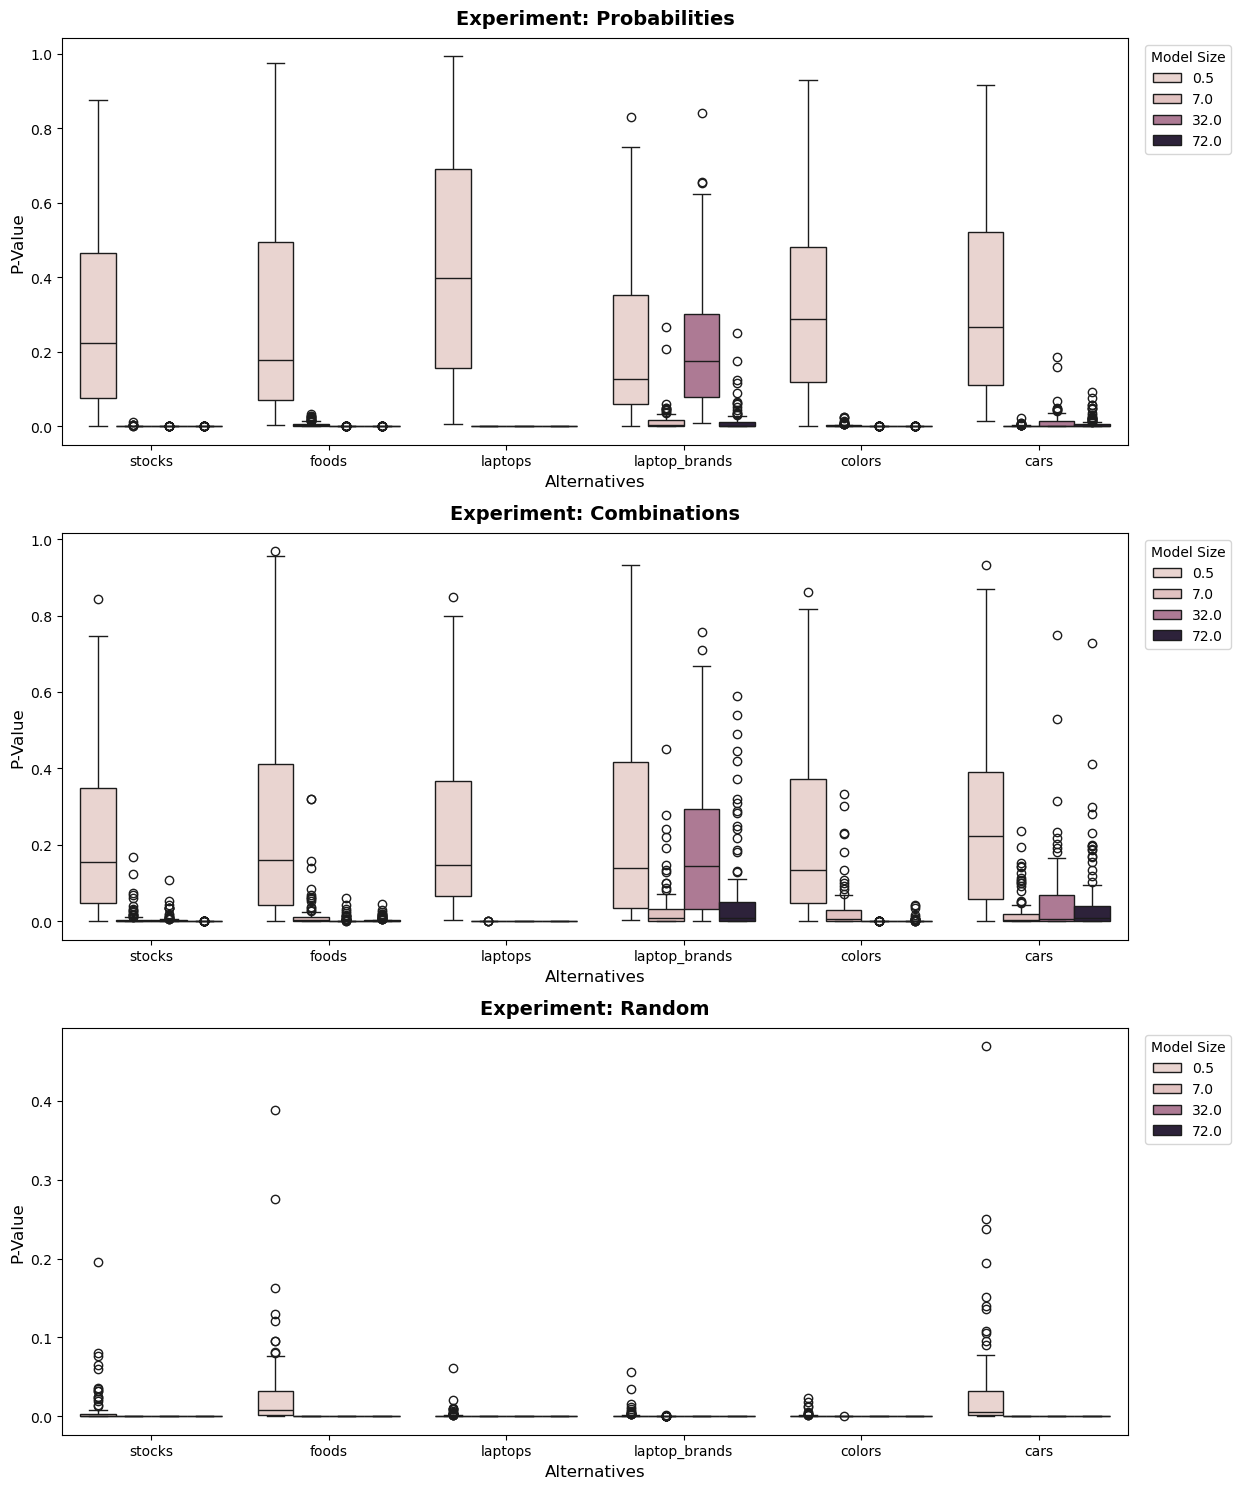

In [17]:
bt_chi2 = pd.read_csv('bt_chi_square_stats.csv')

plot_chi2_results(bt_chi2)

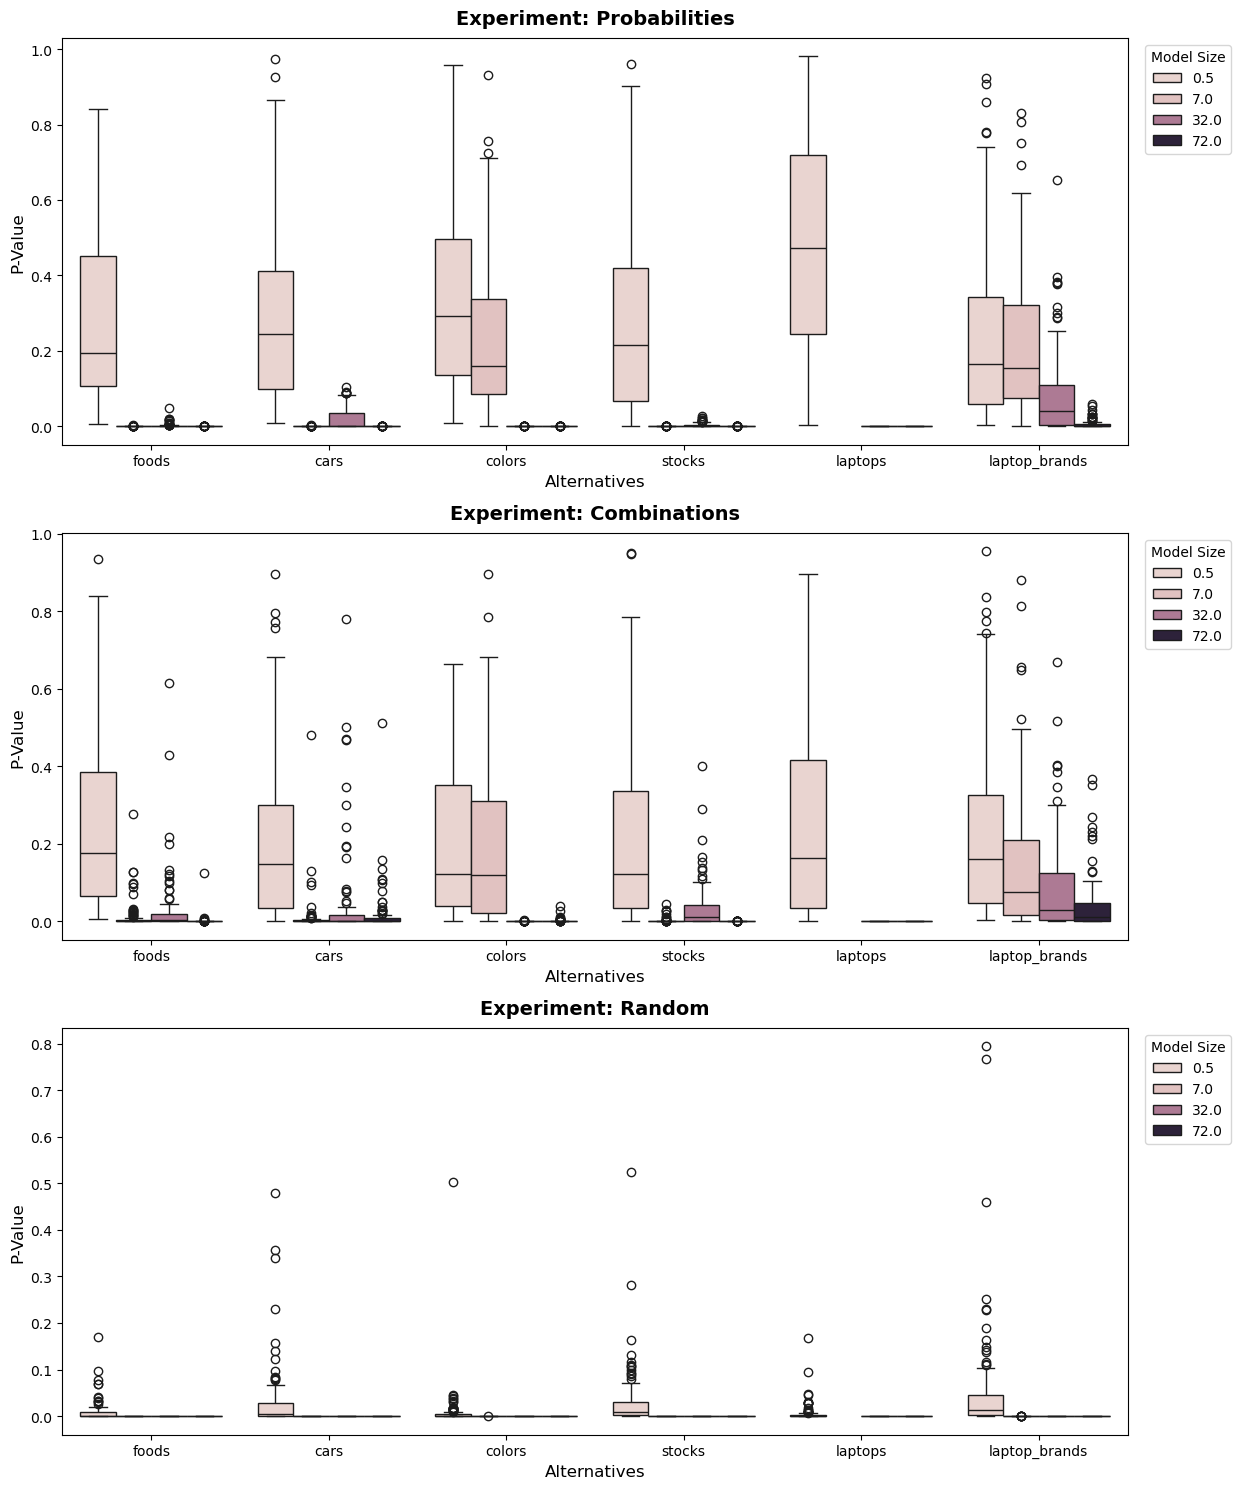

In [15]:
# PMI normalization

bt_chi2 = pd.read_csv('bt_chi_square_stats_pmi.csv')

plot_chi2_results(bt_chi2)

In [79]:

df = bt_chi2.copy()
# 2. Define alphas
alphas = [0.01, 0.05, 0.1, 0.2]

# 3. Calculate condition (p_value > alpha) as boolean columns
for alpha in alphas:
    df[f'alpha_{alpha}'] = df['p_value'] > alpha

# 4. Group by the required columns and calculate the percentage (mean * 100)
for alpha in alphas:
    print(f"Alpha {alpha} Pass Rates:")
    for experiment in df['experiment'].unique():
        print(f"Experiment: {experiment}")
        for alt in df['alternatives'].unique():
            print(f"  Alternatives: {alt}")
            for size in df['model_size'].unique():
                print(f"    Model Size: {size}:", end=' ')
                subset = df[
                    (df['experiment'] == experiment) &
                    (df['alternatives'] == alt) &
                    (df['model_size'] == size)
                ]
                pass_rate = subset[f'alpha_{alpha}'].mean() * 100
                print(f"{pass_rate:.2f}%")

Alpha 0.01 Pass Rates:
Experiment: Probabilities
  Alternatives: foods
    Model Size: 32.0: 3.00%
    Model Size: 72.0: 0.00%
    Model Size: 7.0: 0.00%
    Model Size: 0.5: 96.00%
  Alternatives: cars
    Model Size: 32.0: 23.00%
    Model Size: 72.0: 0.00%
    Model Size: 7.0: 0.00%
    Model Size: 0.5: 97.00%
  Alternatives: colors
    Model Size: 32.0: 0.00%
    Model Size: 72.0: 0.00%
    Model Size: 7.0: 98.00%
    Model Size: 0.5: 97.00%
  Alternatives: stocks
    Model Size: 32.0: 16.00%
    Model Size: 72.0: 0.00%
    Model Size: 7.0: 0.00%
    Model Size: 0.5: 91.00%
  Alternatives: laptops
    Model Size: 32.0: 0.00%
    Model Size: 72.0: 0.00%
    Model Size: 7.0: nan%
    Model Size: 0.5: 98.00%
  Alternatives: laptop_brands
    Model Size: 32.0: 64.00%
    Model Size: 72.0: 17.00%
    Model Size: 7.0: 98.00%
    Model Size: 0.5: 95.00%
Experiment: Combinations
  Alternatives: foods
    Model Size: 32.0: 43.00%
    Model Size: 72.0: 1.00%
    Model Size: 7.0: 12.00%
    M

In [35]:
df = bt_chi2.copy()
df = df[df['alternatives'] == 'stocks']
df.groupby(['model_size', 'experiment'])['p_value'].describe()

count          mean           std           min  \
model_size experiment                                                       
0.5        Combinations   100.0  2.112608e-01  2.103901e-01  9.039864e-05   
           Probabilities  100.0  3.003538e-01  2.538485e-01  4.979375e-04   
           Random         100.0  6.719675e-02  1.127191e-01  5.612028e-05   
7.0        Combinations   100.0  9.529387e-03  2.309836e-02  1.314963e-07   
           Probabilities  100.0  6.533096e-04  1.824938e-03  1.422161e-07   
           Random         100.0  0.000000e+00  0.000000e+00  0.000000e+00   
32.0       Combinations   100.0  4.272646e-03  1.417292e-02  2.361335e-09   
           Probabilities  100.0  1.899391e-05  4.722199e-05  6.600819e-10   
           Random         100.0  0.000000e+00  0.000000e+00  0.000000e+00   
72.0       Combinations   100.0  6.165683e-05  5.348058e-04  0.000000e+00   
           Probabilities  100.0  9.570122e-16  3.668636e-15  0.000000e+00   
           Random         100.0  0.000000e+00  0.000000e+00  0.000000e+00   

                                   25%           50%           75%  \
model_size experiment                                                
0.5        Combinations   4.384824e-02  1.430199e-01  3.301838e-01   
           Probabilities  6.507185e-02  2.395163e-01  4.944255e-01   
           Random         5.269008e-03  2.212470e-02  7.420154e-02   
7.0        Combinations   5.405657e-05  7.590988e-04  5.458923e-03   
           Probabilities  1.542102e-05  7.541584e-05  4.039743e-04   
           Random         0.000000e+00  0.000000e+00  0.000000e+00   
32.0       Combinations   3.598141e-05  2.139921e-04  1.977931e-03   
           Probabilities  4.432740e-07  3.039380e-06  1.459283e-05   
           Random         0.000000e+00  0.000000e+00  0.000000e+00   
72.0       Combinations   2.080739e-10  5.090864e-09  3.766973e-07   
           Probabilities  0.000000e+00  0.000000e+00  2.220446e-16   
           Random         0.000000e+00  0.000000e+00  0.000000e+00   

                                   max  
model_size experiment                   
0.5        Combinations   7.908324e-01  
           Probabilities  9.399994e-01  
           Random         6.673376e-01  
7.0        Combinations   1.514811e-01  
           Probabilities  1.316998e-02  
           Random         0.000000e+00  
32.0       Combinations   9.216127e-02  
           Probabilities  3.042434e-04  
           Random         0.000000e+00  
72.0       Combinations   5.338168e-03  
           Probabilities  2.875478e-14  
           Random         0.000000e+00

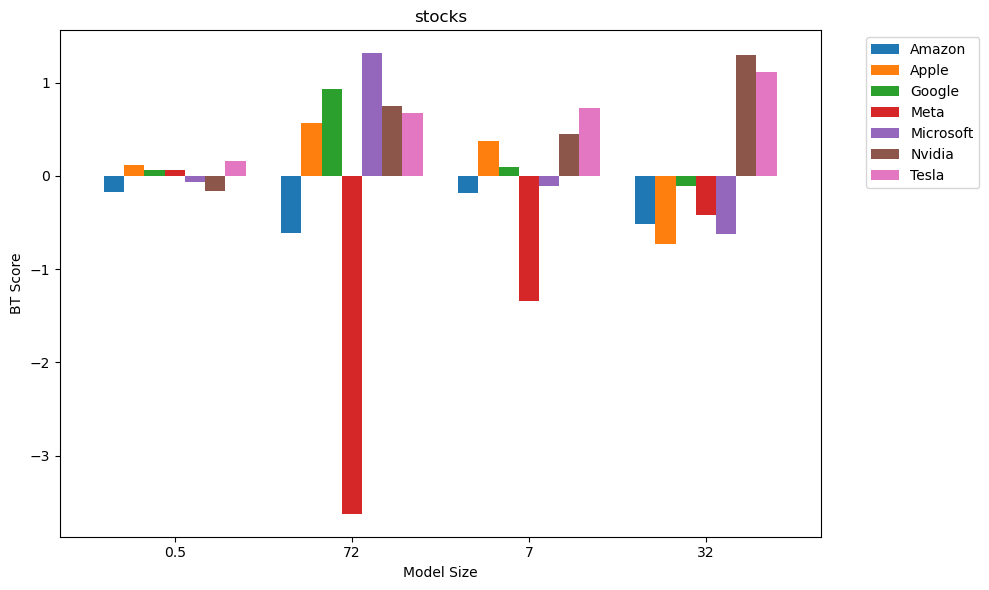

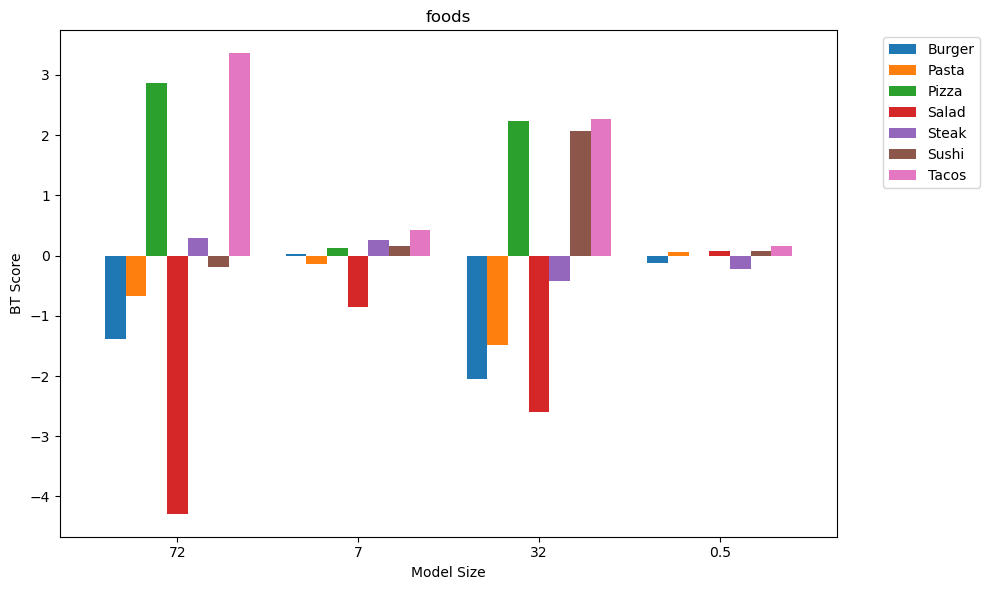

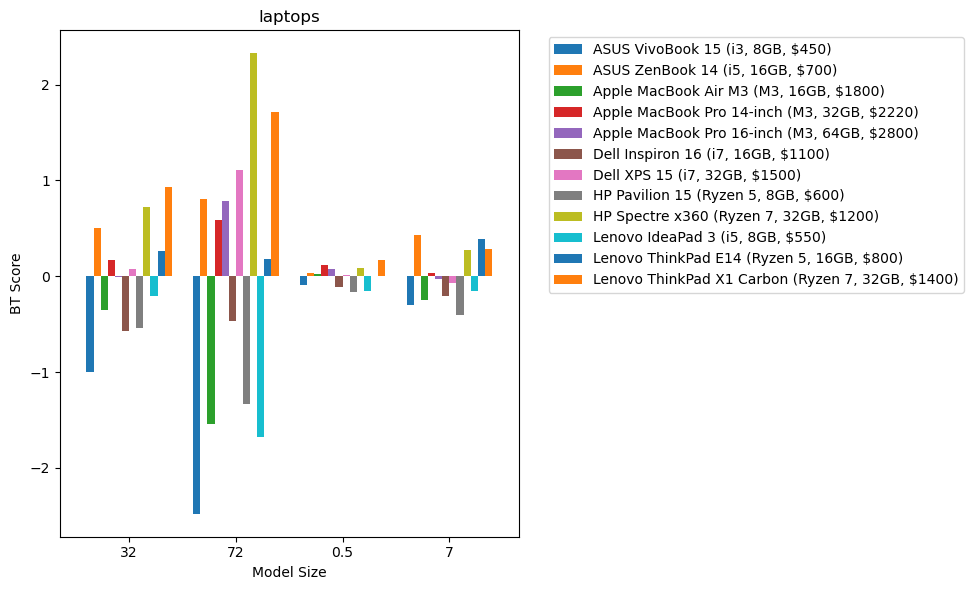

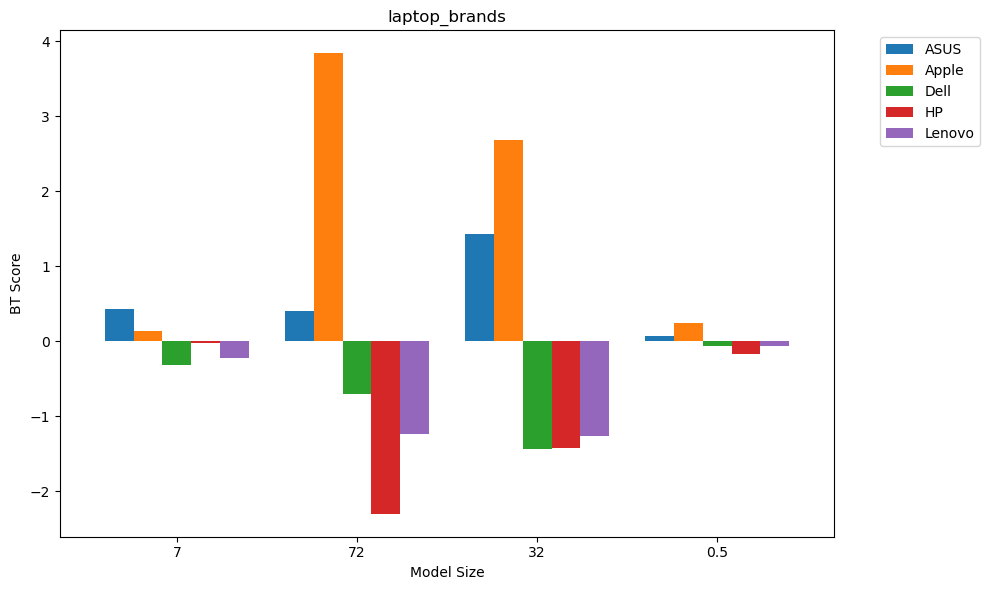

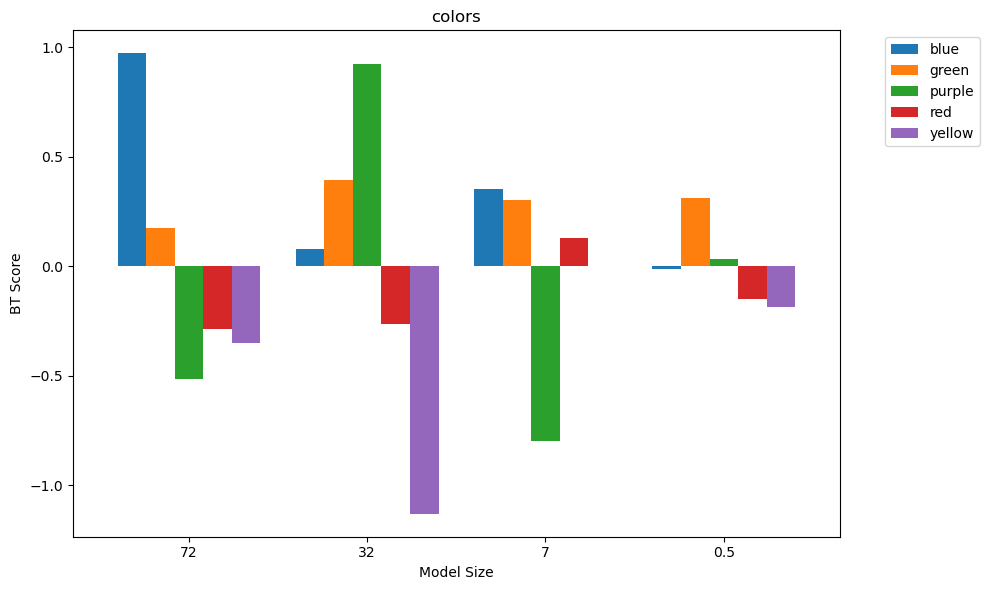

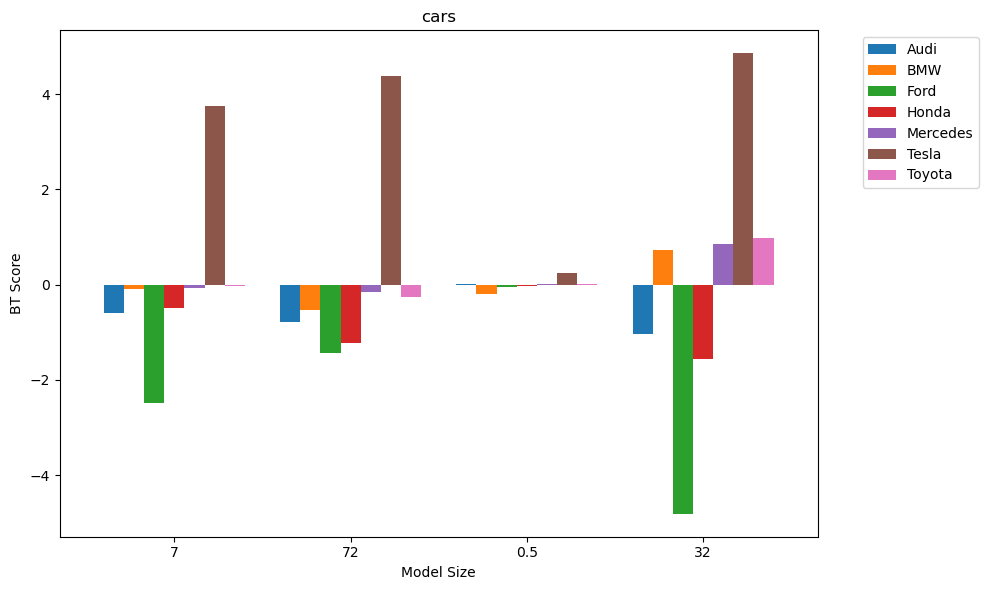

In [72]:
for alternatives in bt_chi2['alternatives'].unique():
    records = []
    for raw_scores, parameters in iterate_experiments('eos_fix_qwen'):
        if not parameters['alternatives'] == alternatives:
            continue
        df_probs = compute_probabilities(raw_scores)
        item_mapping = create_item_mapping(raw_scores)
        bt_scores = fit_bradley_terry(df_probs, item_mapping)
        records.append({
            'model_size': parameters['model_size'],
            **{alt: score for alt, score in zip(item_mapping.keys(), bt_scores)}
        })

    bt_scores_df = pd.DataFrame(records)
    # Create the grouped bar chart
    bt_scores_df.plot(
        x='model_size', 
        kind='bar', 
        figsize=(10, 6), 
        width=0.8 
    )

    # Formatting 
    plt.title(alternatives)
    plt.xlabel('Model Size')
    plt.ylabel('BT Score')
    plt.xticks(rotation=0) # Keeps row labels horizontal
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
    plt.tight_layout()

    plt.show()

# Asserts

In [19]:
# Asserting that the two methods (probabilities vs combinations) yield similar BT scores
mses = []
for raw_scores, parameters in iterate_experiments('eos_fix_qwen'):
    df_probs = compute_probabilities(raw_scores)
    df_combs = aggregate_to_combinations(df_probs)
    item_mapping = create_item_mapping(raw_scores)
    bt_scores_probs = fit_bradley_terry(df_probs, item_mapping)
    df_scores_combs = fit_bradley_terry(df_combs, item_mapping)
    mse = np.mean((bt_scores_probs - df_scores_combs)**2)
    mses.append(mse)
print(f"MSE: {np.mean(mses):.6f} ± {np.std(mses):.6f} (n={len(mses)})")    

MSE: 0.000000 ± 0.000000 (n=24)


In [87]:
# Asserting a synthetic dataset generated from the BT model yields non-significant chi-square tests

# Hard-coded BT scores for 5 items, synthetic dataset generation, and chi-square simulation
items = ['A', 'B', 'C', 'D', 'E']
bt_scores_syn = np.array([1.5, 0.7, 0.0, -0.8, -1.4])
bt_scores_syn = bt_scores_syn - np.mean(bt_scores_syn)  # center

mapping_syn = {item: idx for idx, item in enumerate(items)}

records = []
n_templates = 30
for t in range(n_templates):
    for i, j in itertools.combinations(items, 2):
        p_ij = expit(bt_scores_syn[mapping_syn[i]] - bt_scores_syn[mapping_syn[j]])
        records.append({'template_idx': t, 'option_a': i, 'option_b': j, 'prob_a': p_ij})

df_syn = pd.DataFrame(records)

# Run chi-square simulations
stats_syn = simulate_chi_square_tests(df_syn, bt_scores_syn, mapping_syn, n_trials=200, is_fitted_model=False)

# Summarize results
alpha = 0.05
print(stats_syn['p_value'].describe())
print(f"Percent trials with p > {alpha:.2f}: {(stats_syn['p_value'] > alpha).mean() * 100:.2f}%")

count    200.000000
mean       0.472318
std        0.274033
min        0.003325
25%        0.248950
50%        0.472040
75%        0.713427
max        0.995715
Name: p_value, dtype: float64
Percent trials with p > 0.05: 96.00%


In [15]:
items = ['A', 'B', 'C', 'D', 'E']
bt_scores_syn = np.array([1.5, 0.7, 0.0, -0.8, -1.4])
bt_scores_syn = bt_scores_syn - np.mean(bt_scores_syn)  # center

mapping_syn = {item: idx for idx, item in enumerate(items)}

records = []
n_templates = 30
for t in range(n_templates):
    for i, j in itertools.combinations(items, 2):
        p_ij = expit(bt_scores_syn[mapping_syn[i]] - bt_scores_syn[mapping_syn[j]])
        records.append({'template_idx': t, 'option_a': i, 'option_b': j, 'prob_a': p_ij})

df_syn = pd.DataFrame(records)

bt_learned = fit_bradley_terry(df_syn, mapping_syn)
print("Original BT Scores:", bt_scores_syn)
print("Learned BT Scores:", bt_learned)

# Run chi-square simulations
stats_syn = simulate_chi_square_tests(df_syn, bt_learned, mapping_syn, n_trials=200)

# Summarize results
alpha = 0.05
print(stats_syn['p_value'].describe())
print(f"Percent trials with p > {alpha:.2f}: {(stats_syn['p_value'] > alpha).mean() * 100:.2f}%")

Original BT Scores: [ 1.5000000e+00  7.0000000e-01 -4.4408921e-17 -8.0000000e-01
 -1.4000000e+00]
Learned BT Scores: [ 1.50000013e+00  7.00000321e-01 -9.40489779e-07 -7.99999480e-01
 -1.40000003e+00]
count    200.000000
mean       0.194664
std        0.197501
min        0.000004
25%        0.046660
50%        0.130128
75%        0.299070
max        0.947451
Name: p_value, dtype: float64
Percent trials with p > 0.05: 73.00%


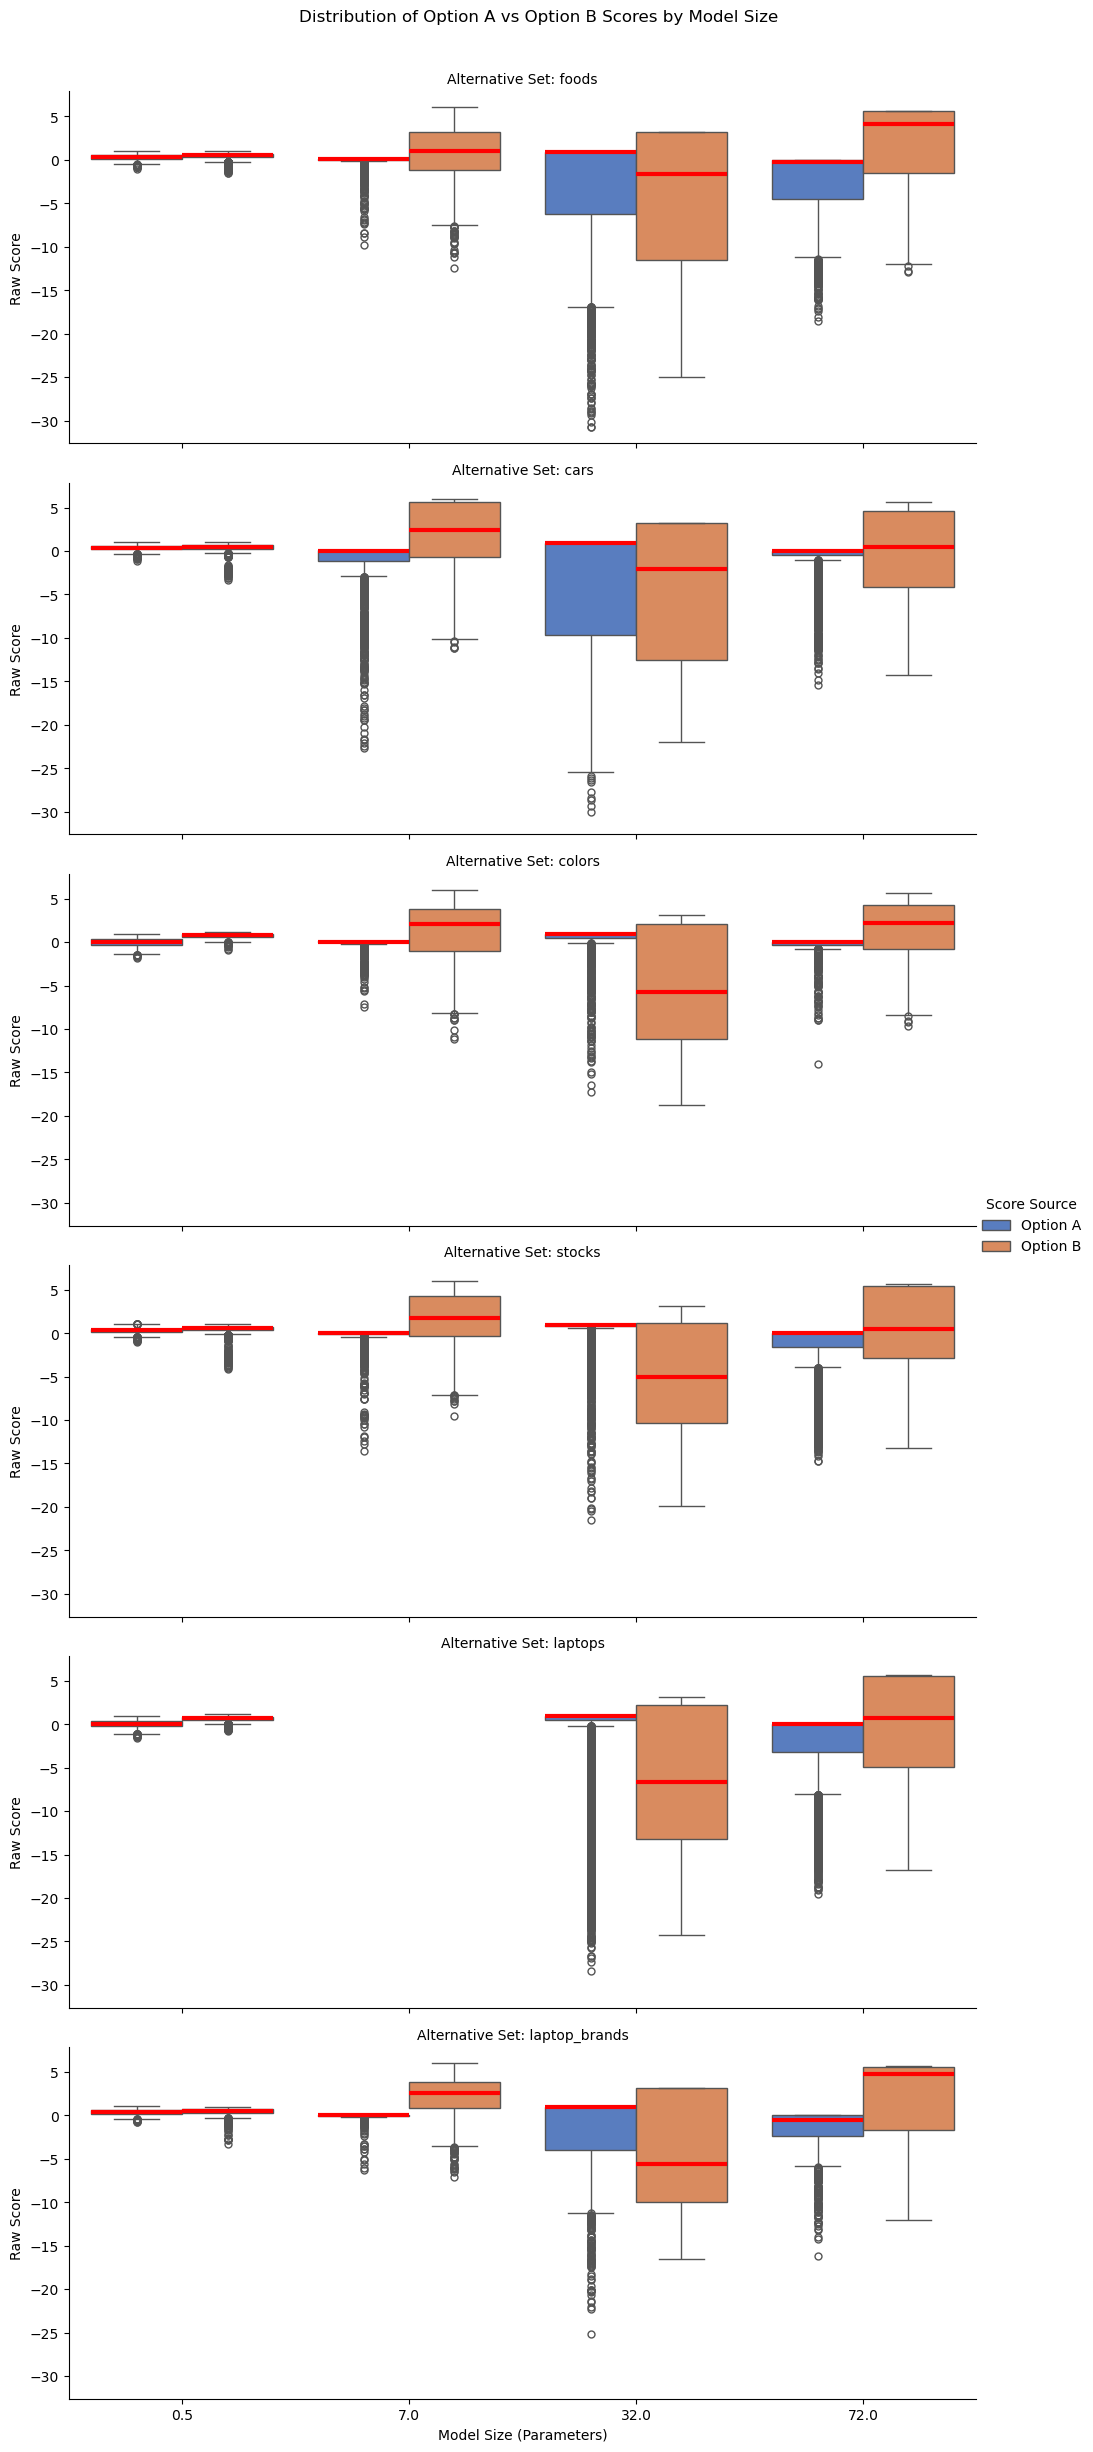

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Create an empty list to store our processed slices
all_scores = []

for raw_scores, parameters in iterate_experiments('pmi_qwen'):
    # df_probs = compute_probabilities(raw_scores)
    # Clean the model size string and convert to float (keeping our previous fix)
    raw_size = str(parameters['model_size'])
    clean_size = re.sub(r'[^\d.]', '', raw_size)
    size_float = float(clean_size) if clean_size else 0.0
    
    # 2. Store BOTH score_a and score_b in our temporary dataframe
    df_subset = pd.DataFrame({
        'alternatives': parameters['alternatives'],
        'model_size': size_float,
        # 'score_a': df_probs['prob_a'],
        # 'score_b': df_probs['prob_b']
        'score_a': raw_scores['score_a'],
        'score_b': raw_scores['score_b']
    })
    all_scores.append(df_subset)

# 3. Concatenate all the individual dataframes into one master dataframe (Wide Format)
wide_df = pd.concat(all_scores, ignore_index=True)

# 4. ---> NEW: "Melt" the dataframe into Long Format for Seaborn's hue parameter
long_df = pd.melt(
    wide_df, 
    id_vars=['alternatives', 'model_size'], # Columns to keep as identifiers
    value_vars=['score_a', 'score_b'],      # Columns to unpivot
    var_name='Score_Type',                  # Name of the new label column
    value_name='Score'                      # Name of the new values column
)

# Extract unique float sizes and sort them numerically for the x-axis
sorted_model_sizes = sorted(long_df['model_size'].unique())

# 5. Plotting using catplot
g = sns.catplot(
    data=long_df,
    kind="box",
    x="model_size",
    y="Score",
    hue="Score_Type",
    row="alternatives",
    order=sorted_model_sizes, 
    height=4,            
    aspect=2.5,          
    sharex=True,
    palette="muted",
    medianprops={'linewidth': 3, 'color': 'red'}
)

# Clean up the visual presentation
g.fig.suptitle('Distribution of Option A vs Option B Scores by Model Size', y=1.02)
g.set_axis_labels('Model Size (Parameters)', 'Raw Score')
g.set_titles(row_template='Alternative Set: {row_name}')

# Optional: Clean up the legend titles
legend = g.legend
if legend:
    legend.set_title("Score Source")
    for t, l in zip(legend.texts, ["Option A", "Option B"]):
        t.set_text(l)

plt.show()

# Pretrained

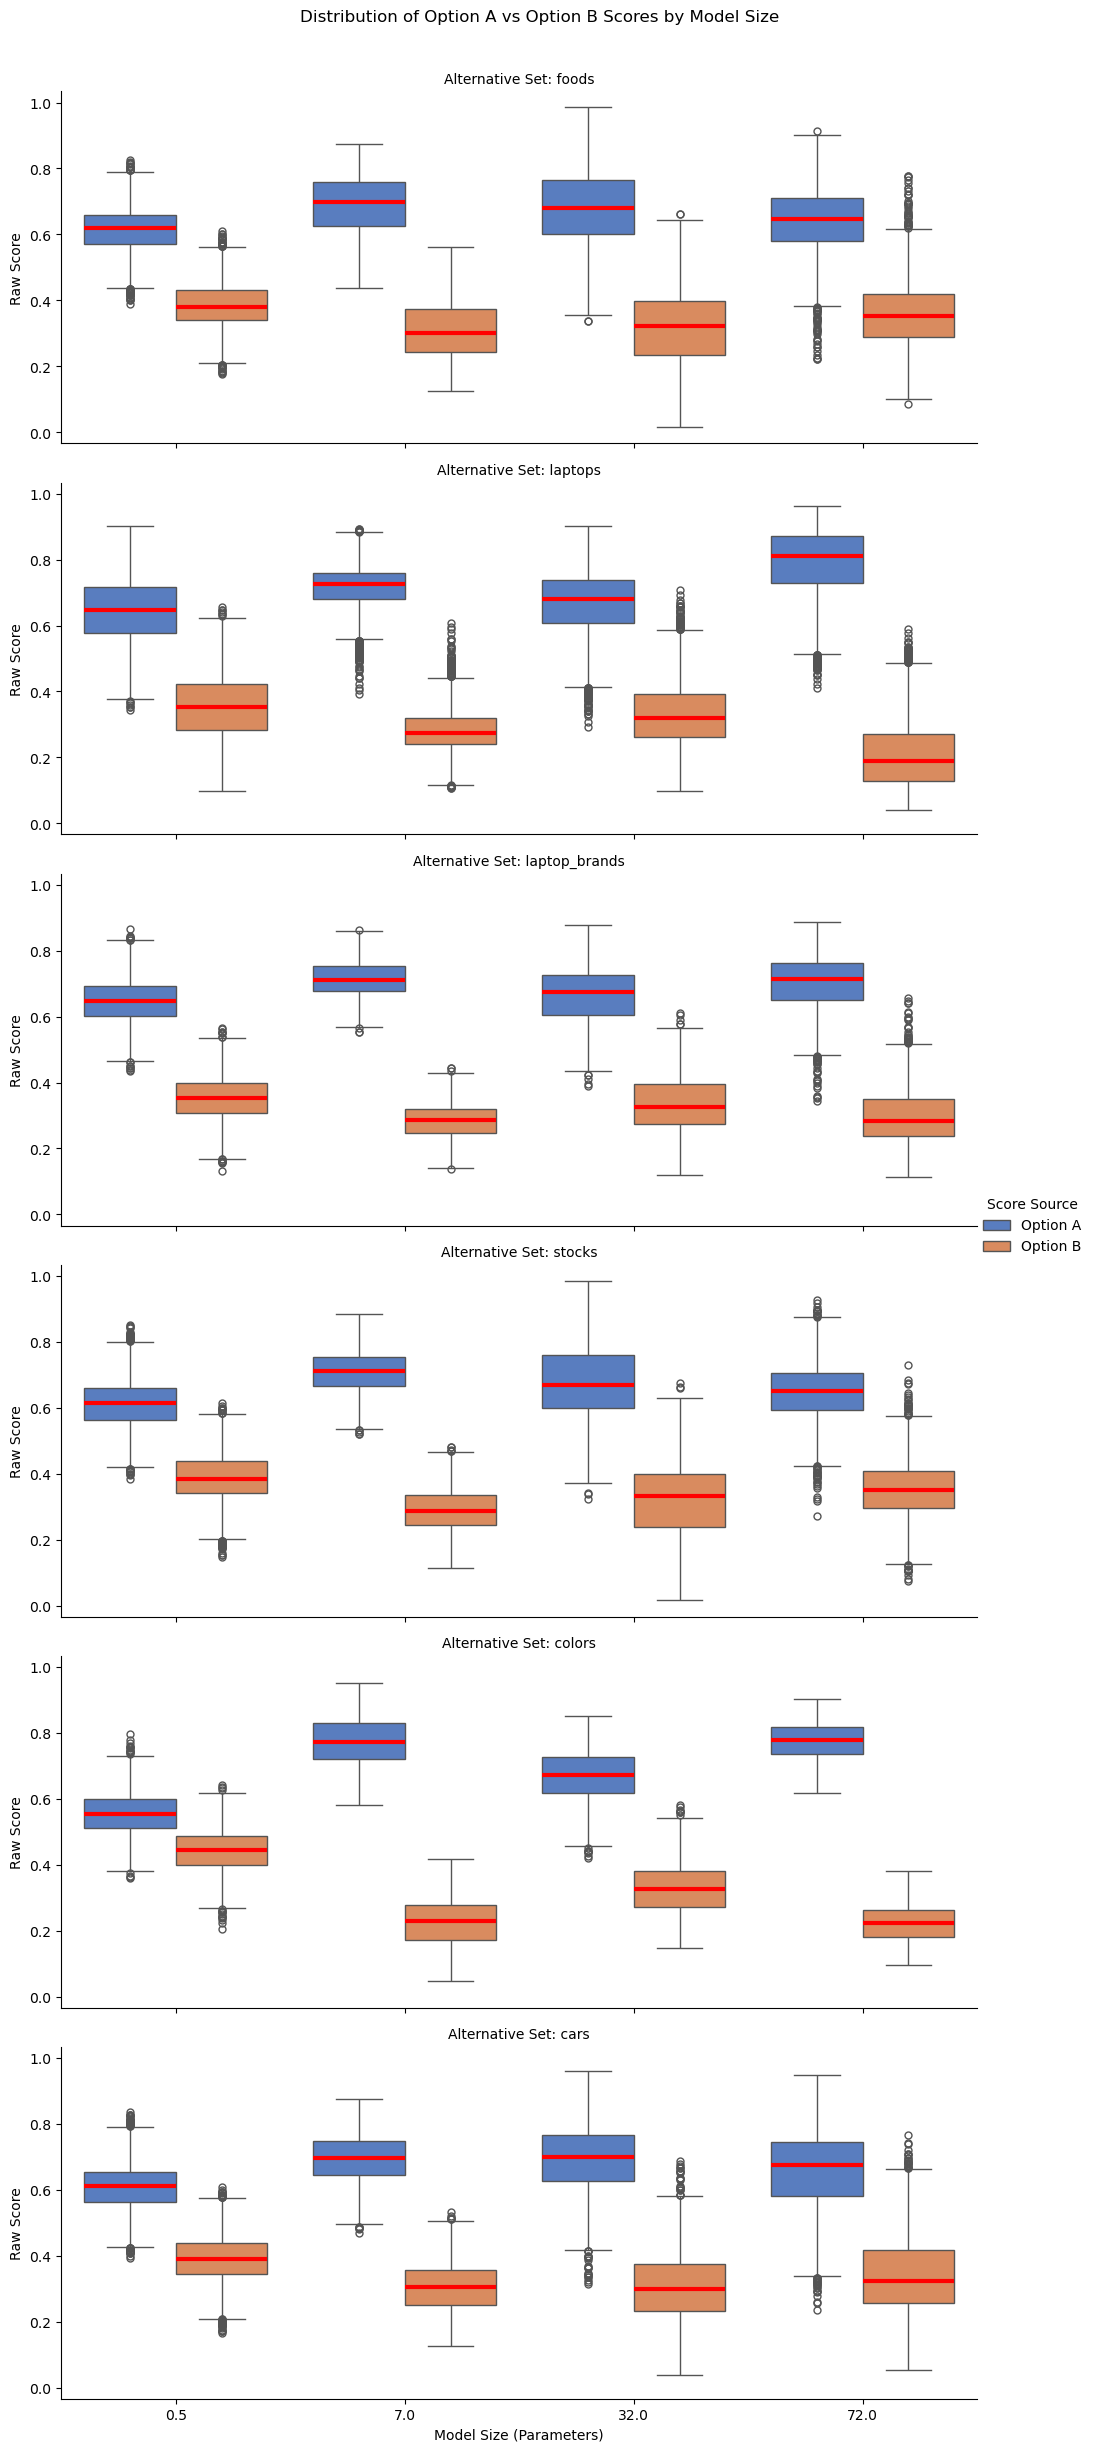

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Create an empty list to store our processed slices
all_scores = []

for raw_scores, parameters in iterate_experiments('qwen_pt'):
    df_probs = compute_probabilities(raw_scores)
    # Clean the model size string and convert to float (keeping our previous fix)
    raw_size = str(parameters['model_size'])
    clean_size = re.sub(r'[^\d.]', '', raw_size)
    size_float = float(clean_size) if clean_size else 0.0
    
    # 2. Store BOTH score_a and score_b in our temporary dataframe
    df_subset = pd.DataFrame({
        'alternatives': parameters['alternatives'],
        'model_size': size_float,
        'score_a': df_probs['prob_a'],
        'score_b': df_probs['prob_b']
        # 'score_a': raw_scores['score_a'],
        # 'score_b': raw_scores['score_b']
    })
    all_scores.append(df_subset)

# 3. Concatenate all the individual dataframes into one master dataframe (Wide Format)
wide_df = pd.concat(all_scores, ignore_index=True)

# 4. ---> NEW: "Melt" the dataframe into Long Format for Seaborn's hue parameter
long_df = pd.melt(
    wide_df, 
    id_vars=['alternatives', 'model_size'], # Columns to keep as identifiers
    value_vars=['score_a', 'score_b'],      # Columns to unpivot
    var_name='Score_Type',                  # Name of the new label column
    value_name='Score'                      # Name of the new values column
)

# Extract unique float sizes and sort them numerically for the x-axis
sorted_model_sizes = sorted(long_df['model_size'].unique())

# 5. Plotting using catplot
g = sns.catplot(
    data=long_df,
    kind="box",
    x="model_size",
    y="Score",
    hue="Score_Type",
    row="alternatives",
    order=sorted_model_sizes, 
    height=4,            
    aspect=2.5,          
    sharex=True,
    palette="muted",
    medianprops={'linewidth': 3, 'color': 'red'}
)

# Clean up the visual presentation
g.fig.suptitle('Distribution of Option A vs Option B Scores by Model Size', y=1.02)
g.set_axis_labels('Model Size (Parameters)', 'Raw Score')
g.set_titles(row_template='Alternative Set: {row_name}')

# Optional: Clean up the legend titles
legend = g.legend
if legend:
    legend.set_title("Score Source")
    for t, l in zip(legend.texts, ["Option A", "Option B"]):
        t.set_text(l)

plt.show()

In [10]:
records = []
for raw_scores, parameters in iterate_experiments('qwen_pt'):
    df_probs = compute_probabilities(raw_scores)
    df_combs = aggregate_to_combinations(df_probs)
    item_mapping = create_item_mapping(raw_scores)
    
    rand_records = []
    for t in range(df_probs['template_idx'].nunique()):
        for a, b in itertools.permutations(item_mapping.keys(), 2):
            rand_records.append({
                'template_idx': t,
                'option_a': a,
                'option_b': b,
                'prob_a': np.random.rand()
            })
    df_random = pd.DataFrame(rand_records)
    
    bt_scores = fit_bradley_terry(df_probs, item_mapping)
    
    for df, label in zip([df_probs, df_combs, df_random], ['Probabilities', 'Combinations', 'Random']):
        stats = simulate_chi_square_tests(df, bt_scores, item_mapping, n_trials=100)
        stats['model_size'] = parameters['model_size']
        stats['alternatives'] = parameters['alternatives']
        stats['experiment'] = label
        records.append(stats)
    
    
final_stats_df = pd.concat(records, ignore_index=True)
final_stats_df.to_csv('bt_chi2_qwen_pt.csv', index=False)

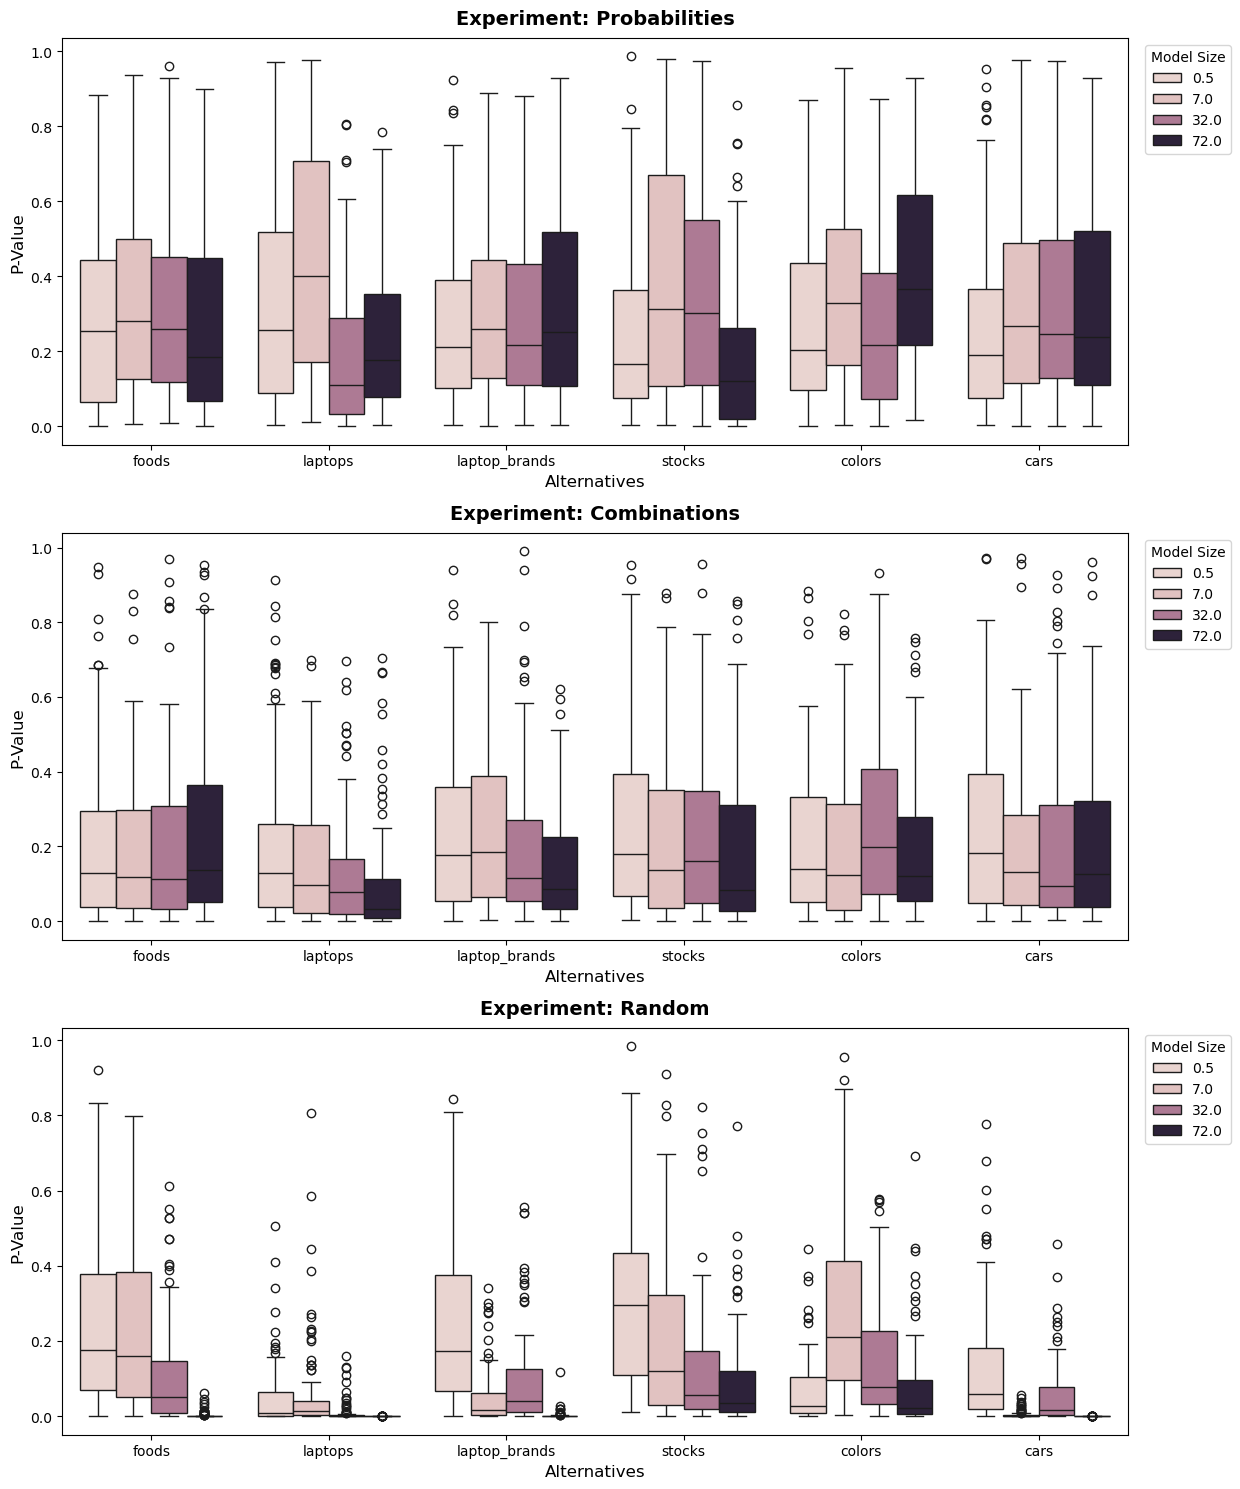

In [14]:
bt_chi2 = pd.read_csv('bt_chi2_qwen_pt.csv')

plot_chi2_results(bt_chi2)
# for label in bt_chi2['experiment'].unique():
#     df = bt_chi2[bt_chi2['experiment'] == label]
#     print(label)

#     g = sns.catplot(
#         data=df,
#         x='alternatives',
#         y='p_value',
#         hue='model_size',
#         kind='box',
#         height=5,
#         aspect=2.5
#     )

#     # Optional formatting
#     # g.set(yscale="log")
#     g.set_axis_labels("Alternatives", "P-Value")
#     g.set_titles("Experiment: {col_name}")
#     plt.tight_layout()
#     plt.show()

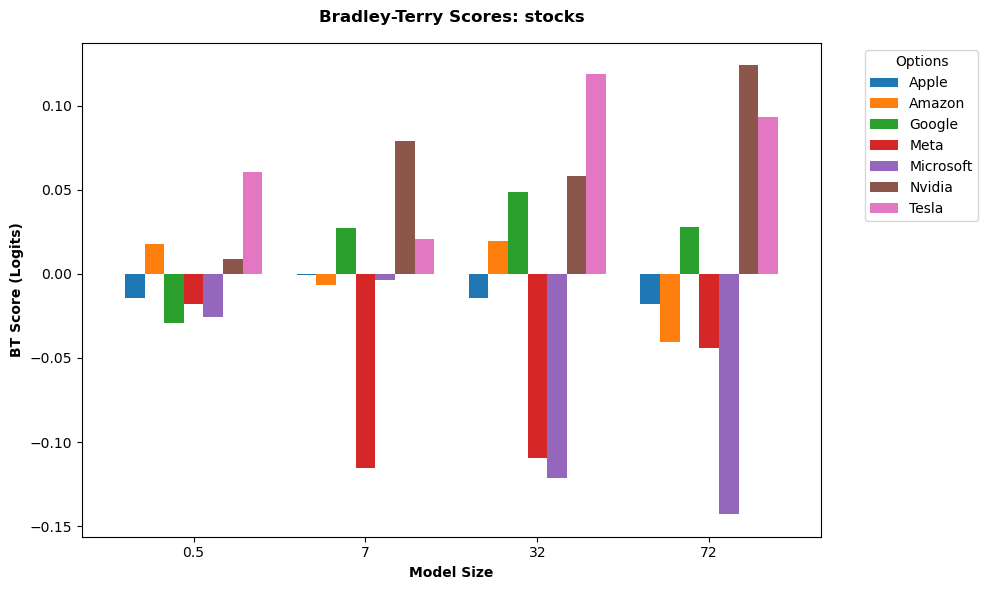

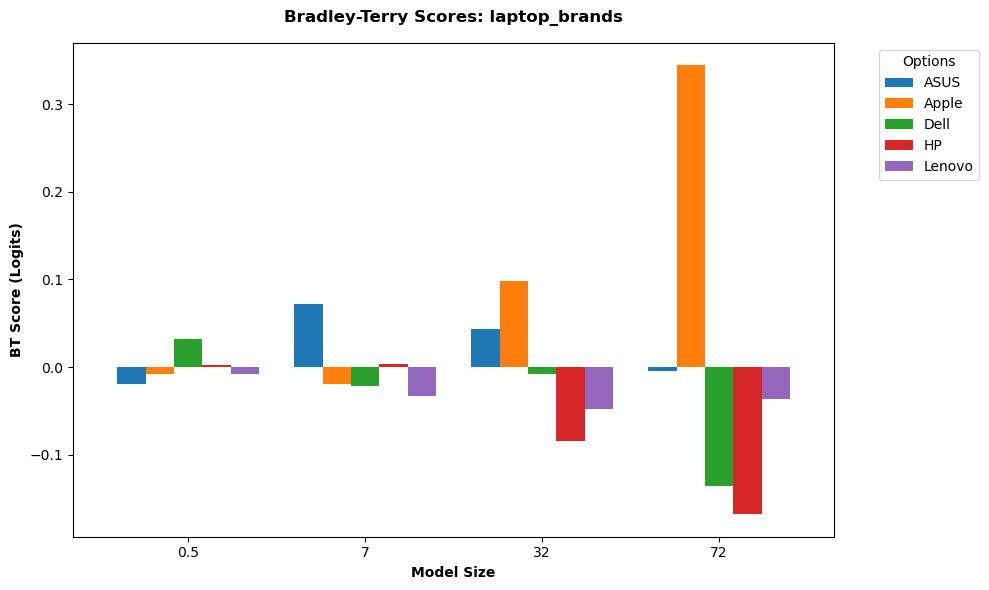

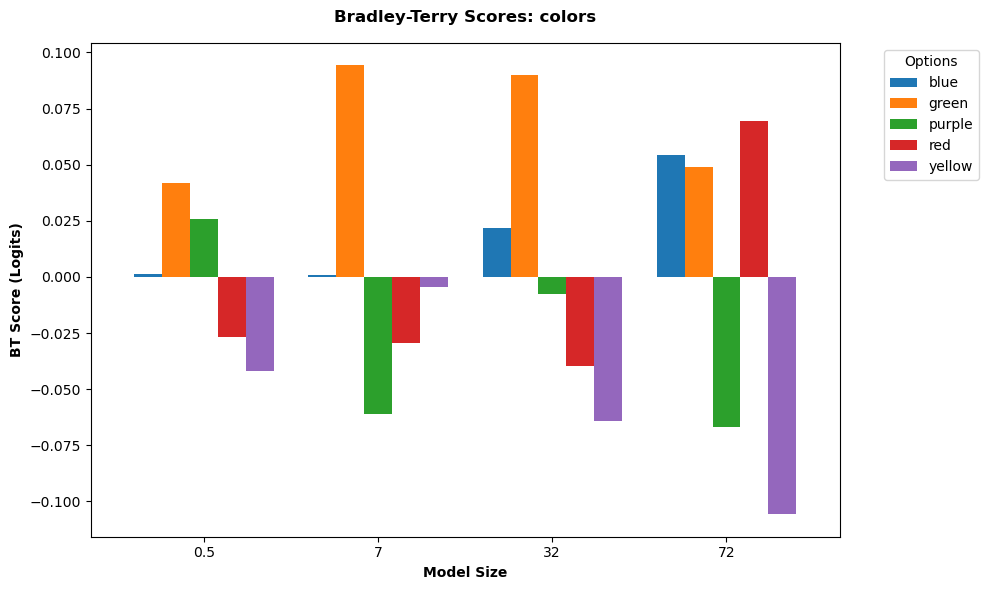

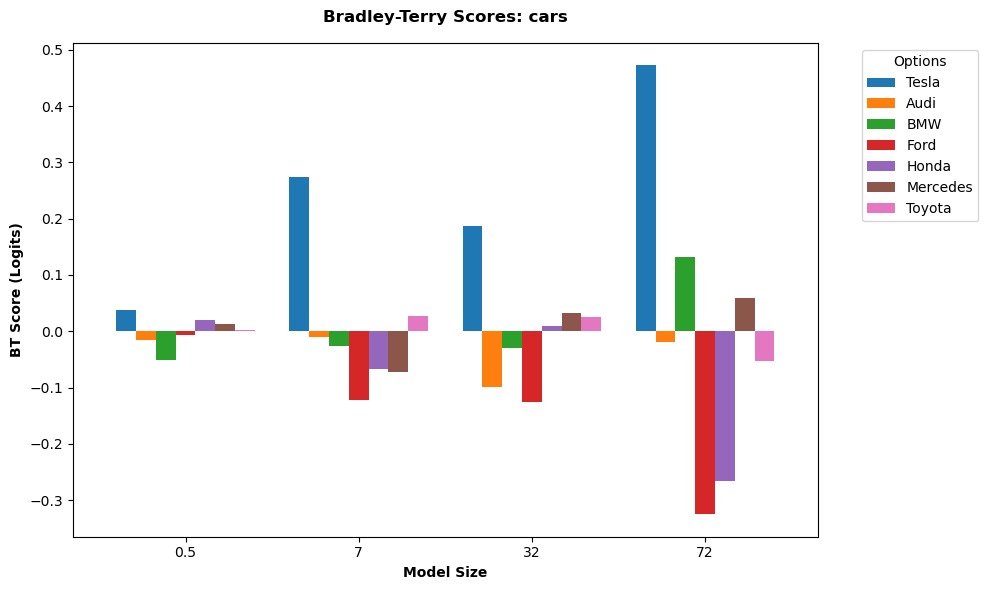

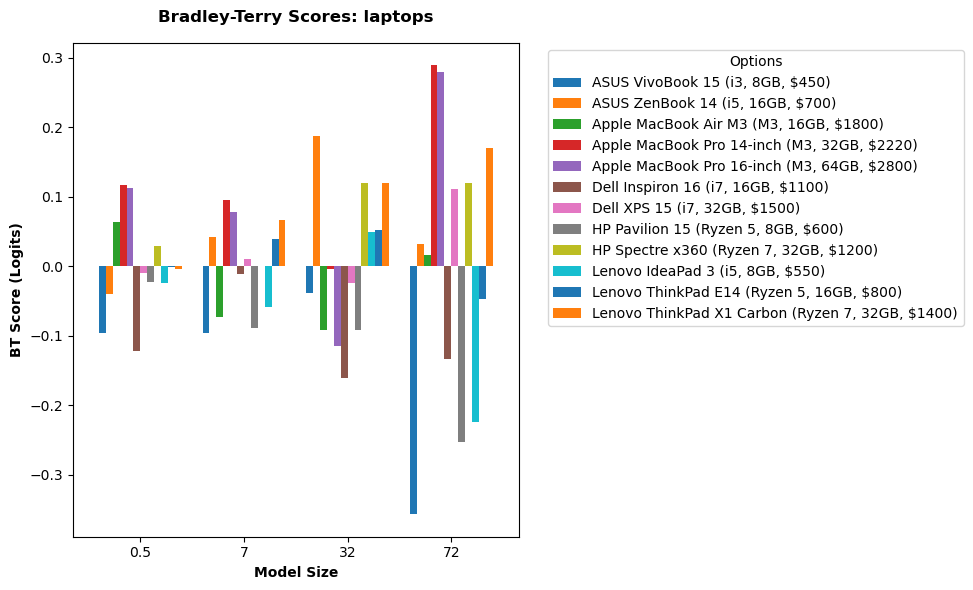

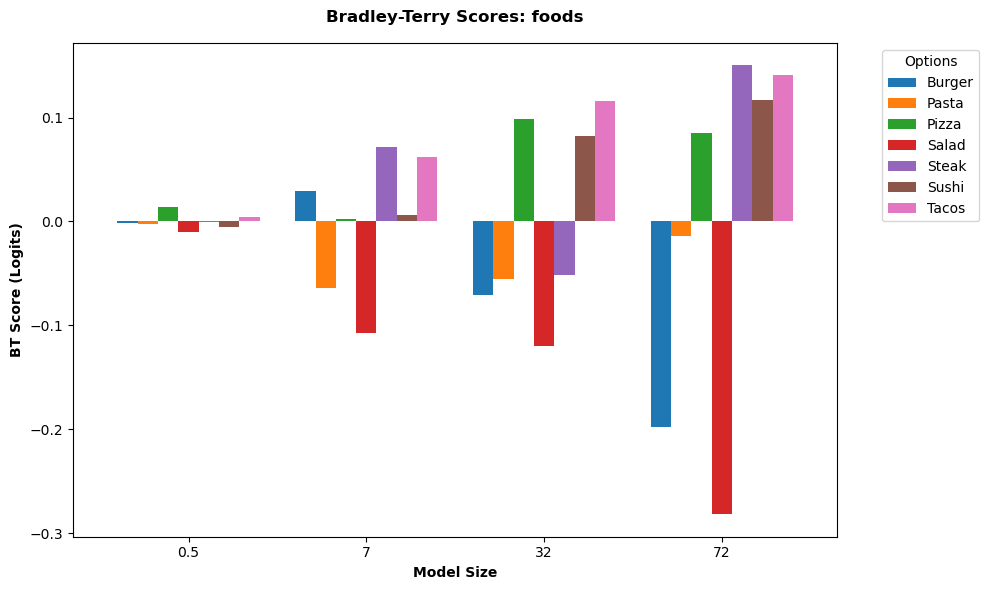

In [20]:
import re
import matplotlib.pyplot as plt
import pandas as pd

def parse_model_size(size_val):
    """
    Extracts magnitude from model size strings (e.g., '500M' -> 5e8, '7B' -> 7e9) 
    so they can be sorted mathematically instead of alphabetically.
    """
    size_str = str(size_val).upper().strip()
    match = re.search(r'([\d\.]+)([KMBT]?)', size_str)
    
    if not match:
        try:
            return float(size_str)
        except ValueError:
            return 0.0
            
    val = float(match.group(1))
    unit = match.group(2)
    
    multipliers = {'K': 1e3, 'M': 1e6, 'B': 1e9, 'T': 1e12}
    return val * multipliers.get(unit, 1.0)


def plot_bt_scores(base_path):
    """
    Reads experiments from a base_path, computes BT scores, and plots 
    grouped bar charts for each alternative set, sorted by model size.
    """
    records = []
    
    # 1. Read the disk once and collect all experiments
    for raw_scores, parameters in iterate_experiments(base_path):
        df_probs = compute_probabilities(raw_scores)
        item_mapping = create_item_mapping(raw_scores)
        bt_scores = fit_bradley_terry(df_probs, item_mapping)
        
        # Build the record combining metadata and the calculated scores
        record = {
            'alternatives': parameters['alternatives'],
            'model_size': parameters['model_size']
        }
        record.update({alt: score for alt, score in zip(item_mapping.keys(), bt_scores)})
        records.append(record)

    if not records:
        print(f"No valid records found in {base_path}")
        return

    # 2. Build master DataFrame and apply proper sorting
    master_df = pd.DataFrame(records)
    master_df['size_num'] = master_df['model_size'].apply(parse_model_size)
    
    # Sort by the extracted numerical value
    master_df = master_df.sort_values('size_num')
    
    # 3. Plot a chart for each unique alternative group
    for alts, group_df in master_df.groupby('alternatives', sort=False):
        
        # Drop the metadata columns
        plot_df = group_df.drop(columns=['alternatives', 'size_num'])
        
        # --> THE FIX: Drop any brand columns that are entirely NaN for this specific group
        plot_df = plot_df.dropna(axis=1, how='all')
        
        # Create the grouped bar chart
        plot_df.plot(
            x='model_size', 
            kind='bar', 
            figsize=(10, 6), 
            width=0.8 
        )

        # Formatting 
        plt.title(f"Bradley-Terry Scores: {alts}", fontweight='bold', pad=15)
        plt.xlabel('Model Size', fontweight='bold')
        plt.ylabel('BT Score (Logits)', fontweight='bold')
        plt.xticks(rotation=0) 
        
        # Move the legend outside the plot
        plt.legend(title="Options", bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()

# --- How to call it ---
plot_bt_scores('qwen_pt')
# plot_bt_scores('llama_pt')

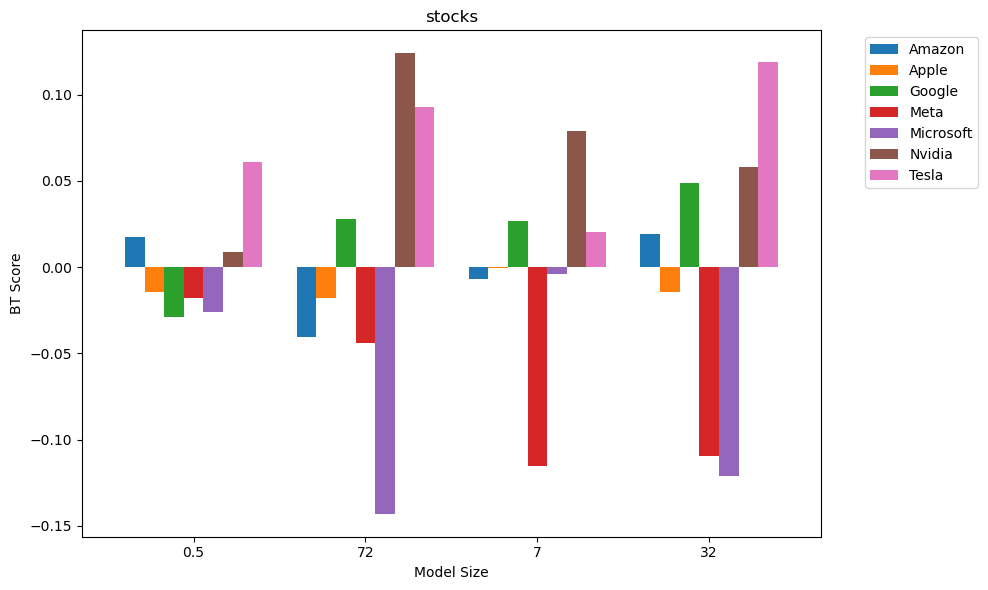

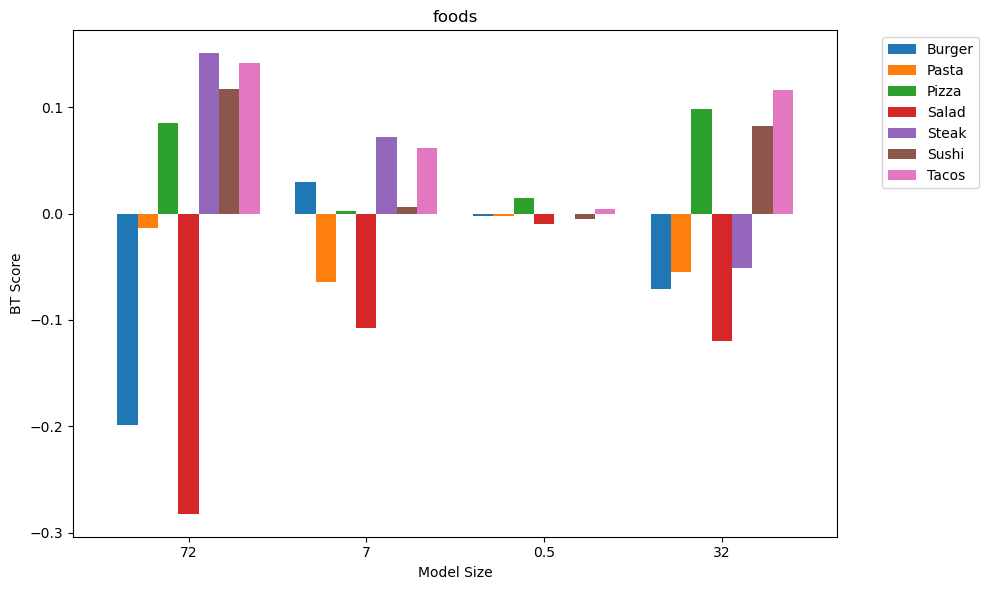

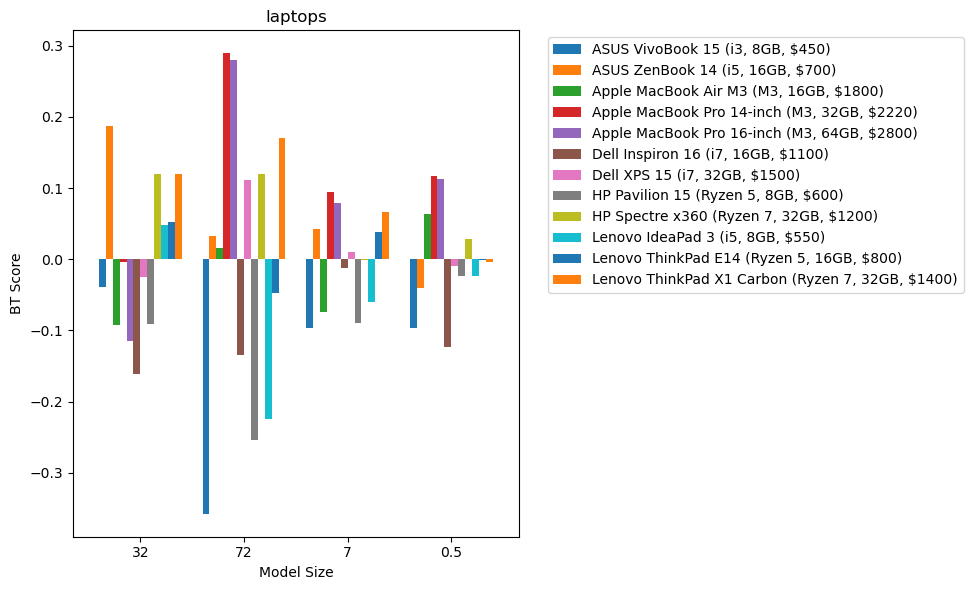

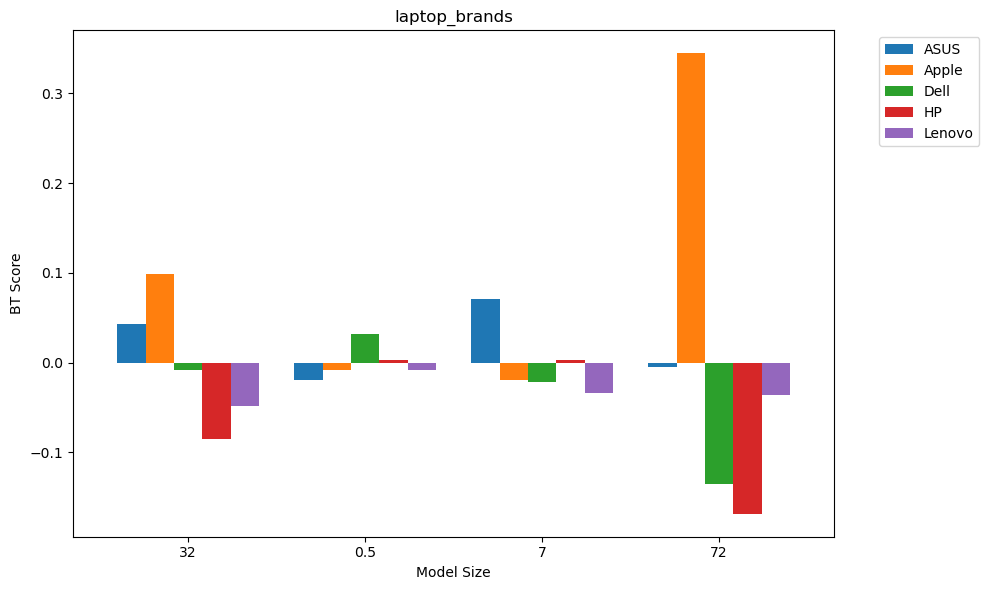

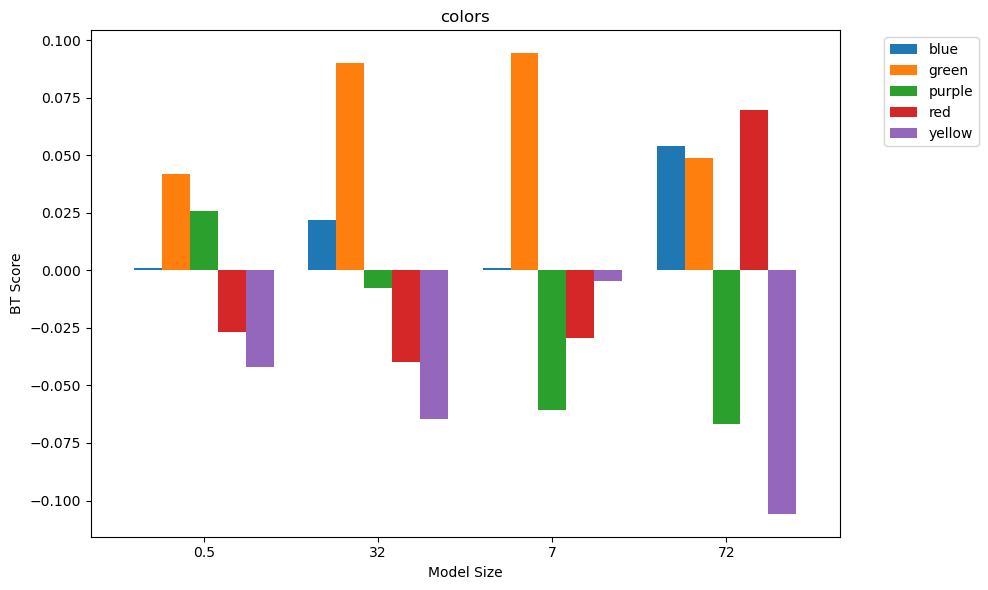

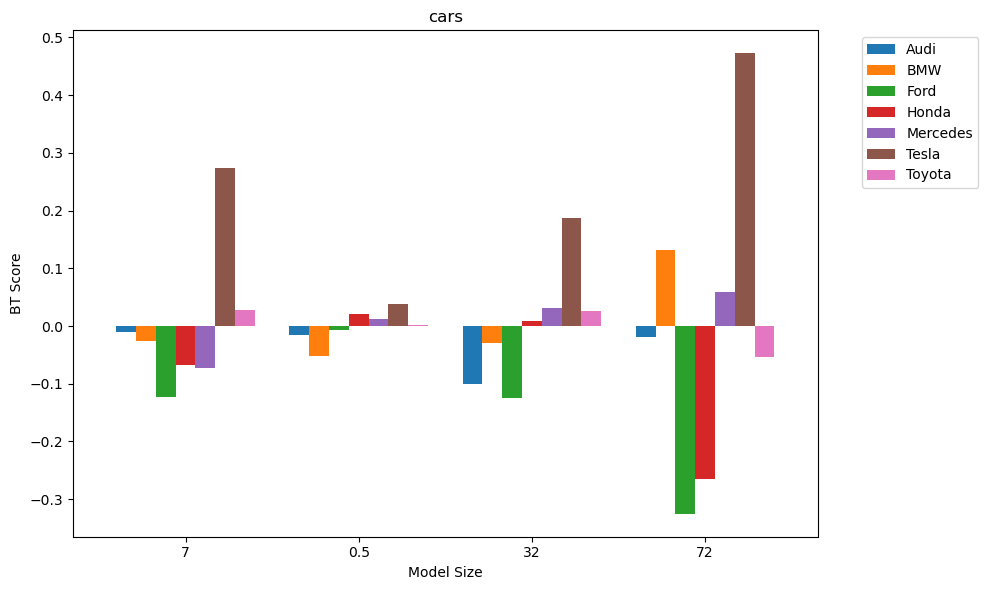

In [18]:
for alternatives in bt_chi2['alternatives'].unique():
    records = []
    for raw_scores, parameters in iterate_experiments('qwen_pt'):
        if not parameters['alternatives'] == alternatives:
            continue
        df_probs = compute_probabilities(raw_scores)
        item_mapping = create_item_mapping(raw_scores)
        bt_scores = fit_bradley_terry(df_probs, item_mapping)
        records.append({
            'model_size': parameters['model_size'],
            **{alt: score for alt, score in zip(item_mapping.keys(), bt_scores)}
        })

    bt_scores_df = pd.DataFrame(records)
    # Create the grouped bar chart
    bt_scores_df.plot(
        x='model_size', 
        kind='bar', 
        figsize=(10, 6), 
        width=0.8 
    )

    # Formatting 
    plt.title(alternatives)
    plt.xlabel('Model Size')
    plt.ylabel('BT Score')
    plt.xticks(rotation=0) # Keeps row labels horizontal
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
    plt.tight_layout()

    plt.show()

# BT with bias

In [35]:
import statsmodels.api as sm

import numpy as np
import pandas as pd
import statsmodels.api as sm

def fit_bradley_terry_statsmodels(df: pd.DataFrame, item_mapping: dict, 
                              item_i_col='option_a', item_j_col='option_b',
                              score_a_col='score_a', score_b_col='score_b') -> dict:
    """
    Fits the Bradley-Terry model with Positional Bias and returns a structured dictionary.
    """
    n_samples = len(df)
    n_items = len(item_mapping)
    
    # 1. Target Variable Y (Log-Odds)
    Y = (df[score_a_col] - df[score_b_col]).values
    
    # 2. Design Matrix X
    X_base = np.zeros((n_samples, n_items))
    i_indices = df[item_i_col].map(item_mapping).values
    j_indices = df[item_j_col].map(item_mapping).values
    
    row_indices = np.arange(n_samples)
    X_base[row_indices, i_indices] = 1
    X_base[row_indices, j_indices] = -1
    
    # Drop the last item column to avoid perfect multicollinearity
    X_base = X_base[:, :-1] 
    
    # Add the Intercept for gamma (Positional Bias)
    X = sm.add_constant(X_base) 
    
    # 3. Fit the OLS Model
    model = sm.OLS(Y, X)
    results = model.fit()
    
    # 4. Extract Bias and P-Value
    # 'const' is always at index 0 in statsmodels when using add_constant
    gamma_bias = results.params[0]
    gamma_pvalue = results.pvalues[0]
    
    # 5. Extract and format Item Scores
    # The coefficients for the items start at index 1. 
    # We append a 0.0 for the reference item we dropped earlier.
    raw_item_scores = np.append(results.params[1:], 0.0)
    
    # Mean-center the scores so they are centered around 0 (standard for BT models)
    centered_scores = raw_item_scores - np.mean(raw_item_scores)
    
    # Reverse the mapping to get {index: 'ItemName'}
    idx_to_item = {idx: item for item, idx in item_mapping.items()}
    
    # Create a dictionary of {ItemName: Score}
    item_scores_dict = {idx_to_item[i]: score for i, score in enumerate(centered_scores)}
    
    # 6. Compile the final dictionary
    output_dict = {
        "item_scores": item_scores_dict,
        "positional_bias_gamma": gamma_bias,
        "gamma_pvalue": gamma_pvalue,
        "model_r_squared": results.rsquared, # Good to keep for diagnostics!
        "f_stat_pvalue": results.f_pvalue    # Tests if the whole model is significant
    }
    
    return output_dict

In [56]:
def record_bt_bias_results(base_dir):
    records = {}
    for raw_scores, parameters in iterate_experiments(base_dir):
        print(f"Processing experiment with parameters: {parameters}", end=' ')
        item_mapping = create_item_mapping(raw_scores)
        
        results = fit_bradley_terry_statsmodels(raw_scores, item_mapping)
        
        alternatives = parameters['alternatives']
        model_size = parameters['model_size']
        if alternatives not in records:
            records[alternatives] = {}
        records[alternatives][model_size] = {
            'results': results,
        }
        
    with open(f"{base_dir}_bt_bias.json", "w") as file:
        json.dump(records, file, indent=4)    

In [57]:
record_bt_bias_results('qwen_pt')

Processing experiment with parameters: {'alternatives': 'foods', 'model_family': 'qwen-pt', 'model_size': '72'} Processing experiment with parameters: {'alternatives': 'laptops', 'model_family': 'qwen-pt', 'model_size': '32'} Processing experiment with parameters: {'alternatives': 'laptop_brands', 'model_family': 'qwen-pt', 'model_size': '32'} Processing experiment with parameters: {'alternatives': 'stocks', 'model_family': 'qwen-pt', 'model_size': '0.5'} Processing experiment with parameters: {'alternatives': 'laptop_brands', 'model_family': 'qwen-pt', 'model_size': '0.5'} Processing experiment with parameters: {'alternatives': 'colors', 'model_family': 'qwen-pt', 'model_size': '0.5'} Processing experiment with parameters: {'alternatives': 'laptops', 'model_family': 'qwen-pt', 'model_size': '72'} Processing experiment with parameters: {'alternatives': 'stocks', 'model_family': 'qwen-pt', 'model_size': '72'} Processing experiment with parameters: {'alternatives': 'cars', 'model_family'

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

def parse_results_to_dataframe(json_data: dict) -> pd.DataFrame:
    """Flattens the nested JSON results and encodes model_size as an Ordered Category."""
    rows = []
    
    # 1. Collect all unique model sizes to establish the categorical order
    unique_sizes = set()
    for alt_set, sizes in json_data.items():
        for size_str in sizes.keys():
            unique_sizes.add(float(size_str))
            
    # Sort them numerically so the categorical order is strictly ascending
    sorted_sizes = sorted(list(unique_sizes))
    cat_order = [f"{size:g}B" for size in sorted_sizes]

    # 2. Extract the data
    for alt_set, sizes in json_data.items():
        for size_str, payload in sizes.items():
            model_size_num = float(size_str)
            model_size_label = f"{model_size_num:g}B" 
            
            results = payload["results"]
            
            # Extract standard metrics
            gamma = results["positional_bias_gamma"]
            r_squared = results["model_r_squared"]
            
            # ---> THE FIX: Extract the p-values <---
            gamma_pvalue = results["gamma_pvalue"]
            f_stat_pvalue = results["f_stat_pvalue"]
            
            for item, score in results["item_scores"].items():
                rows.append({
                    "alt_set": alt_set,
                    "model_size_label": model_size_label,
                    "item": item,
                    "score": score,
                    "gamma": gamma,
                    "r_squared": r_squared,
                    "gamma_pvalue": gamma_pvalue,    # Added to DataFrame
                    "f_stat_pvalue": f_stat_pvalue   # Added to DataFrame
                })
                
    df = pd.DataFrame(rows)
    
    # 3. Cast the label column as a strictly ordered categorical type
    df['model_size_label'] = pd.Categorical(
        df['model_size_label'], 
        categories=cat_order, 
        ordered=True
    )
    
    return df

def plot_llm_preferences(df_results: pd.DataFrame):
    """Generates the analysis plots using a 2-column grid for the preference trajectories."""
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    alt_sets = df_results['alt_set'].unique()
    n_sets = len(alt_sets)
    
    # ---------------------------------------------------------
    # PLOT 1: Evolution of Latent Preferences (N x 2 Grid)
    # ---------------------------------------------------------
    # Dynamic grid calculation: 2 columns, (n+1)//2 rows
    if n_sets == 1:
        rows, cols = 1, 1
    else:
        cols = 2
        rows = (n_sets + 1) // 2
        
    # Adjust figsize so the plots don't get squished (e.g., 6 width per col, 5 height per row)
    fig1, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows), sharey=False)
    
    # Flatten axes for easy zipping, handling the edge case where it's a single plot
    axes_flat = [axes] if n_sets == 1 else axes.flatten()
    
    for ax, alt_set in zip(axes_flat, alt_sets):
        subset = df_results[df_results['alt_set'] == alt_set]
        
        # Sort values to ensure lines connect logically from smallest to largest model
        subset = subset.sort_values(by='model_size_label')
        
        sns.lineplot(
            data=subset, x='model_size_label', y='score', hue='item', 
            marker='o', linewidth=2.5, ax=ax
        )
        ax.set_title(f"Set: {alt_set.capitalize()}", fontweight='bold')
        ax.set_ylabel("Bradley-Terry Score (Log-Odds)")
        ax.set_xlabel("Model Size Class")
        ax.axhline(0, color='black', linestyle='--', alpha=0.5)
        
        # Move legend outside of each subplot
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        
    # Clean up: If we have an odd number of sets > 1, the last subplot is empty. Hide it.
    for i in range(n_sets, len(axes_flat)):
        fig1.delaxes(axes_flat[i])
        
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # PLOT 2 & 3: Bias and Model Fit (Categorical)
    # ---------------------------------------------------------
    df_meta = df_results[['model_size_label', 'alt_set', 'gamma', 'r_squared']].drop_duplicates()
    df_meta = df_meta.sort_values(by='model_size_label')

    # This keeps the Bias and Fit plots side-by-side at the bottom
    fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Bias vs Scale
    sns.lineplot(
        data=df_meta, x='model_size_label', y='gamma', hue='alt_set', 
        marker='s', linewidth=2.5, ax=ax2a
    )
    ax2a.set_title("Positional Bias ($\gamma$) vs. Scale Class", fontweight='bold')
    ax2a.set_ylabel("Gamma (Intercept)")
    ax2a.set_xlabel("Model Size Class")
    ax2a.axhline(0, color='red', linestyle='--', alpha=0.5)

    # R-squared vs Scale
    sns.lineplot(
        data=df_meta, x='model_size_label', y='r_squared', hue='alt_set', 
        marker='^', linewidth=2.5, ax=ax2b
    )
    ax2b.set_title("Model Fit ($R^2$) vs. Scale Class", fontweight='bold')
    ax2b.set_ylabel("Variance Explained ($R^2$)")
    ax2b.set_xlabel("Model Size Class")
    ax2b.set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.show()
    
def plot_statistical_significance(df_results: pd.DataFrame):
    """Generates Negative Log10 P-Value plots for the model parameters."""
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    # Extract just the meta-parameters
    df_meta = df_results[['model_size_label', 'alt_set', 'gamma_pvalue', 'f_stat_pvalue']].drop_duplicates()
    
    # 1. Prevent log(0) errors by clipping exact 0.0s to the float limit
    min_float = 1e-300
    df_meta['gamma_pvalue'] = df_meta['gamma_pvalue'].replace(0.0, min_float)
    df_meta['f_stat_pvalue'] = df_meta['f_stat_pvalue'].replace(0.0, min_float)
    
    # 2. Transform to -log10 space
    df_meta['neg_log_gamma_p'] = -np.log10(df_meta['gamma_pvalue'])
    df_meta['neg_log_f_p'] = -np.log10(df_meta['f_stat_pvalue'])

    # 3. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- PLOT A: Significance of Positional Bias ---
    sns.lineplot(
        data=df_meta, x='model_size_label', y='neg_log_gamma_p', 
        hue='alt_set', marker='s', linewidth=2.5, ax=ax1
    )
    ax1.set_title("Significance of Positional Bias ($\gamma$)", fontweight='bold')
    ax1.set_ylabel("$-\\log_{10}$(p-value)")
    ax1.set_xlabel("Model Size Class")
    
    # Add the standard alpha = 0.05 threshold line
    threshold = -np.log10(0.05)
    ax1.axhline(threshold, color='red', linestyle='--', alpha=0.8, label='p = 0.05')
    ax1.legend()

    # --- PLOT B: Significance of the Overall Model ---
    sns.lineplot(
        data=df_meta, x='model_size_label', y='neg_log_f_p', 
        hue='alt_set', marker='^', linewidth=2.5, ax=ax2
    )
    ax2.set_title("Significance of Model Fit (F-Statistic)", fontweight='bold')
    ax2.set_ylabel("$-\\log_{10}$(p-value)")
    ax2.set_xlabel("Model Size Class")
    ax2.axhline(threshold, color='red', linestyle='--', alpha=0.8, label='p = 0.05')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

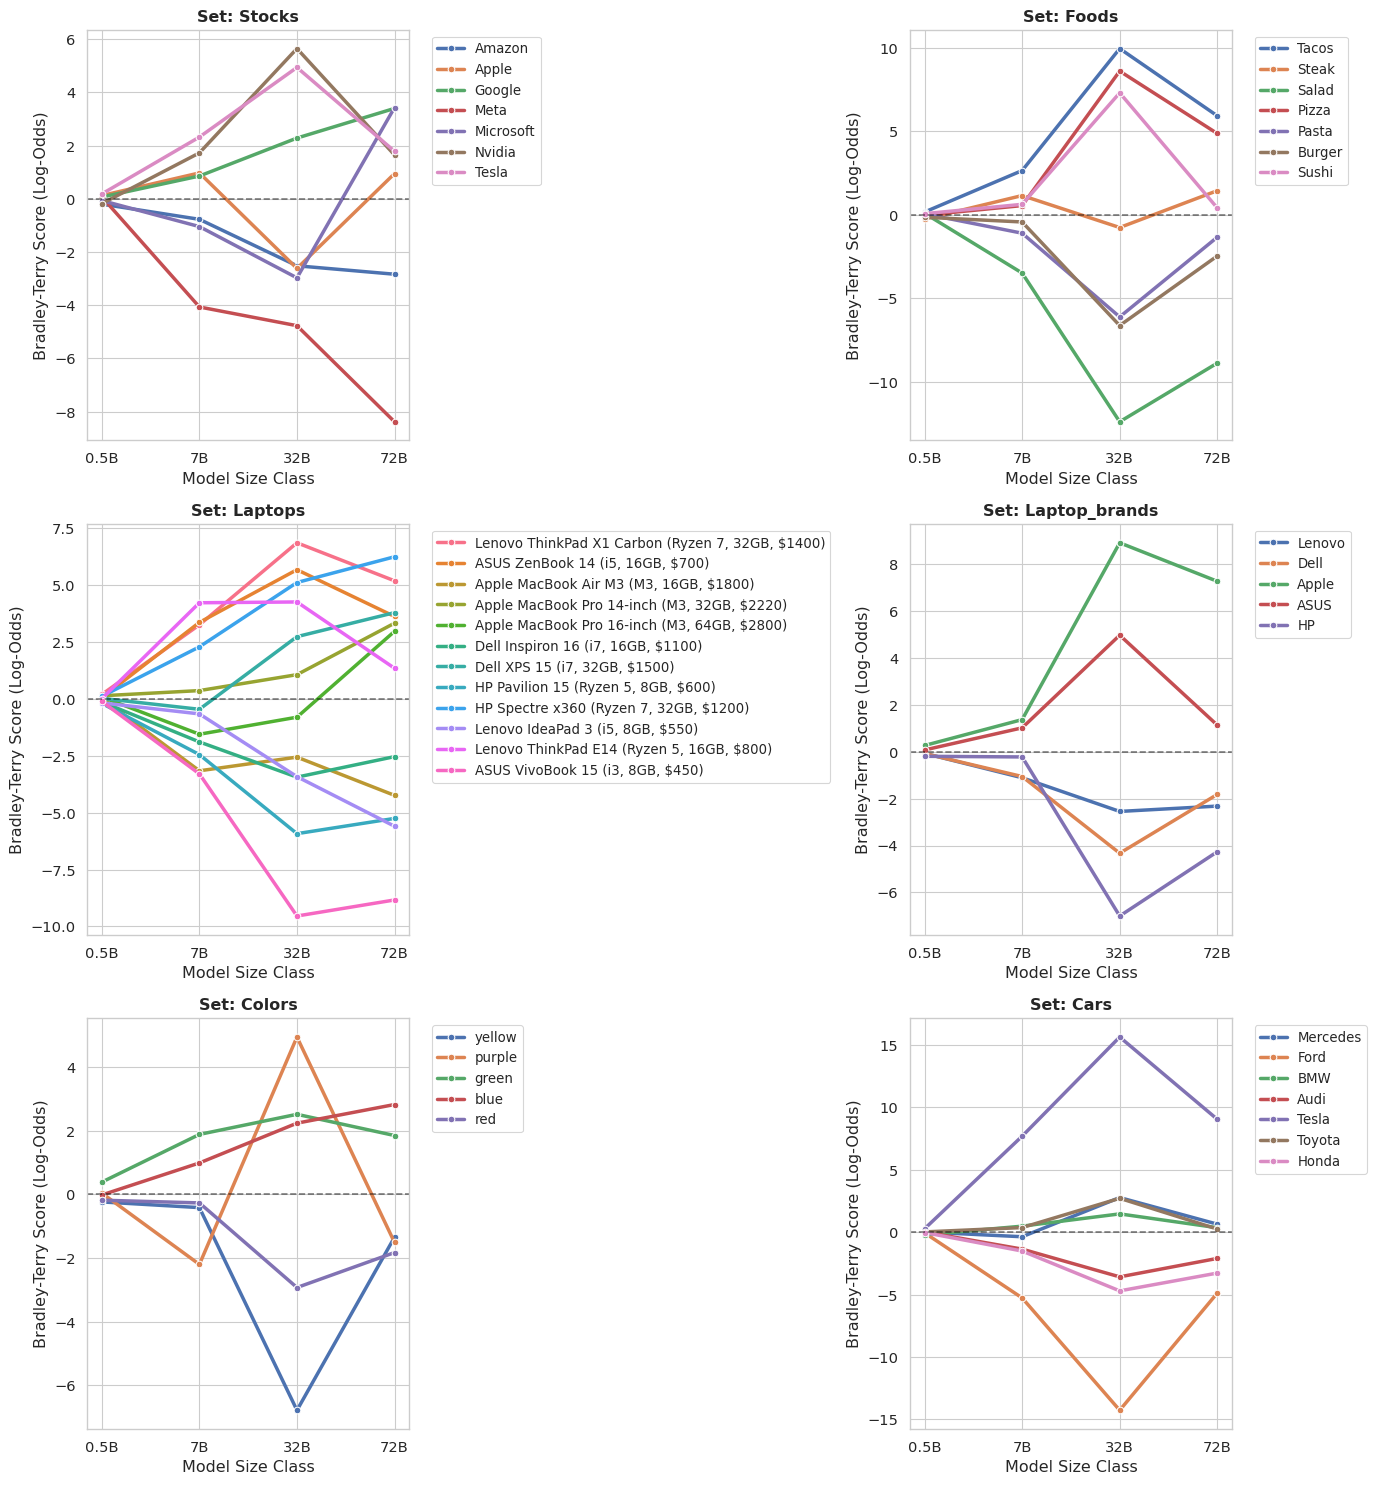

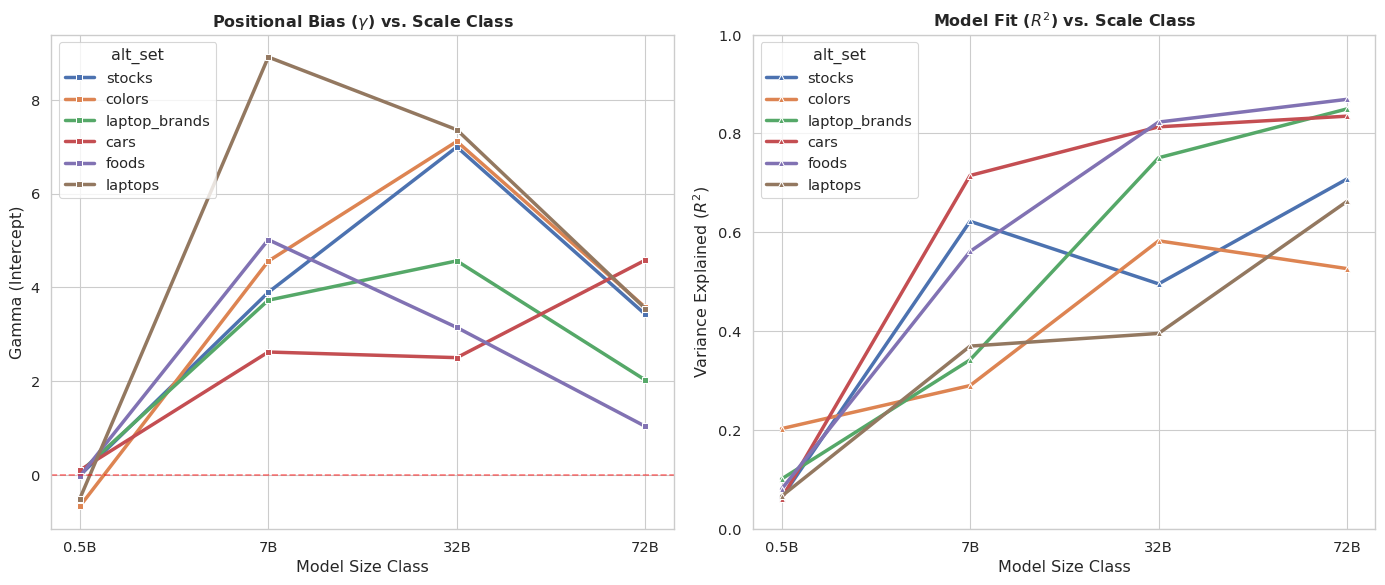

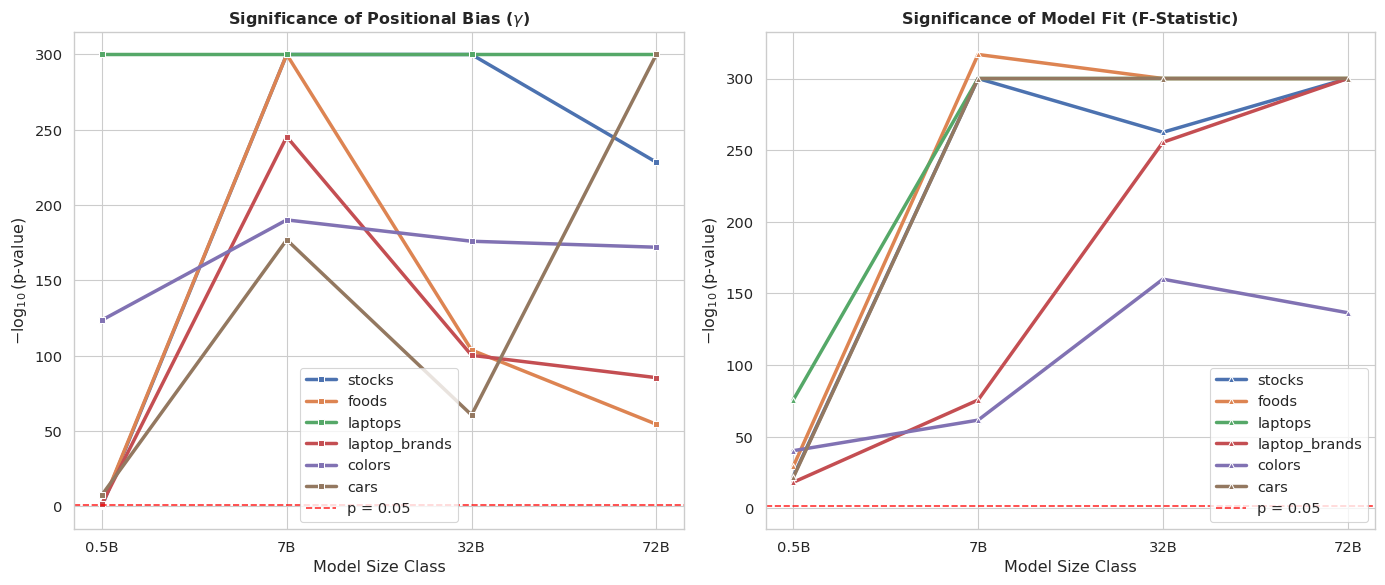

In [61]:
with open("eos_fix_qwen_bt_bias.json", "r") as file:
    data = json.load(file)
df = parse_results_to_dataframe(data)
plot_llm_preferences(df)
plot_statistical_significance(df)

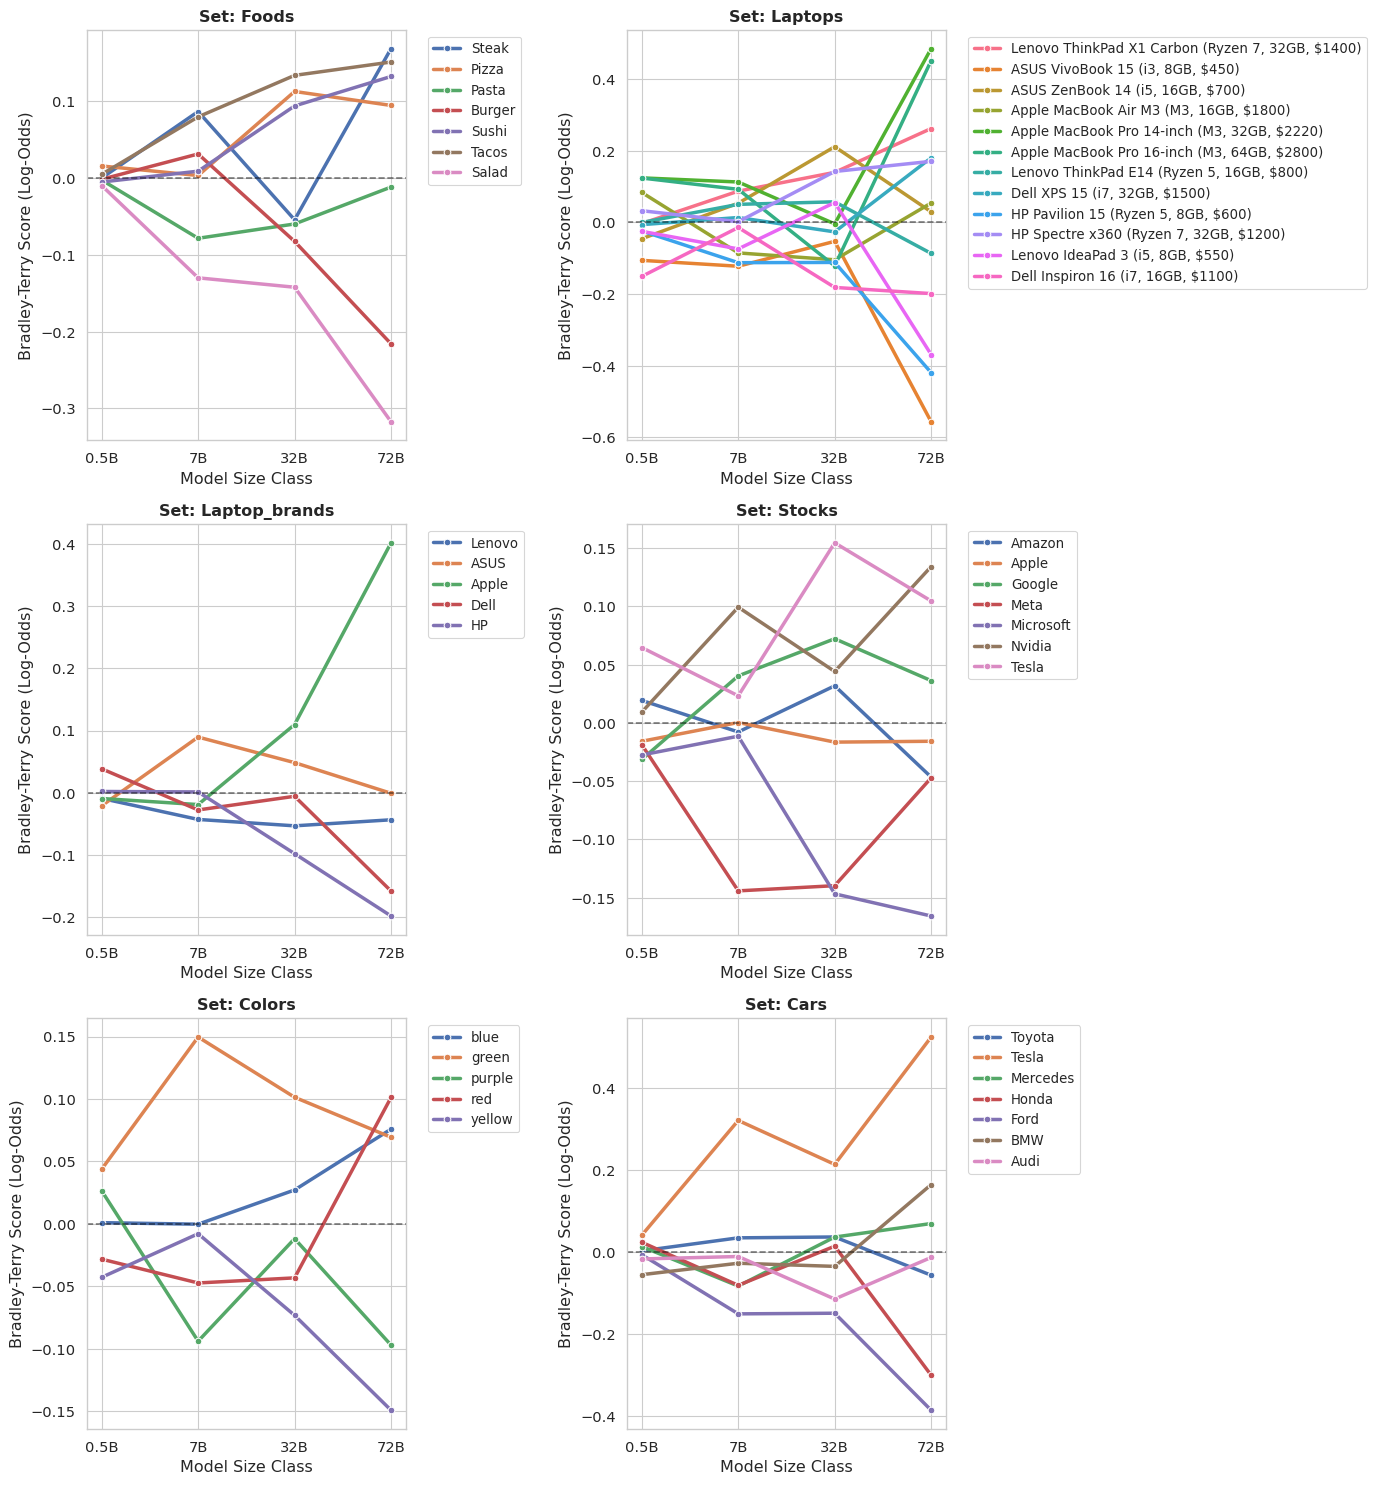

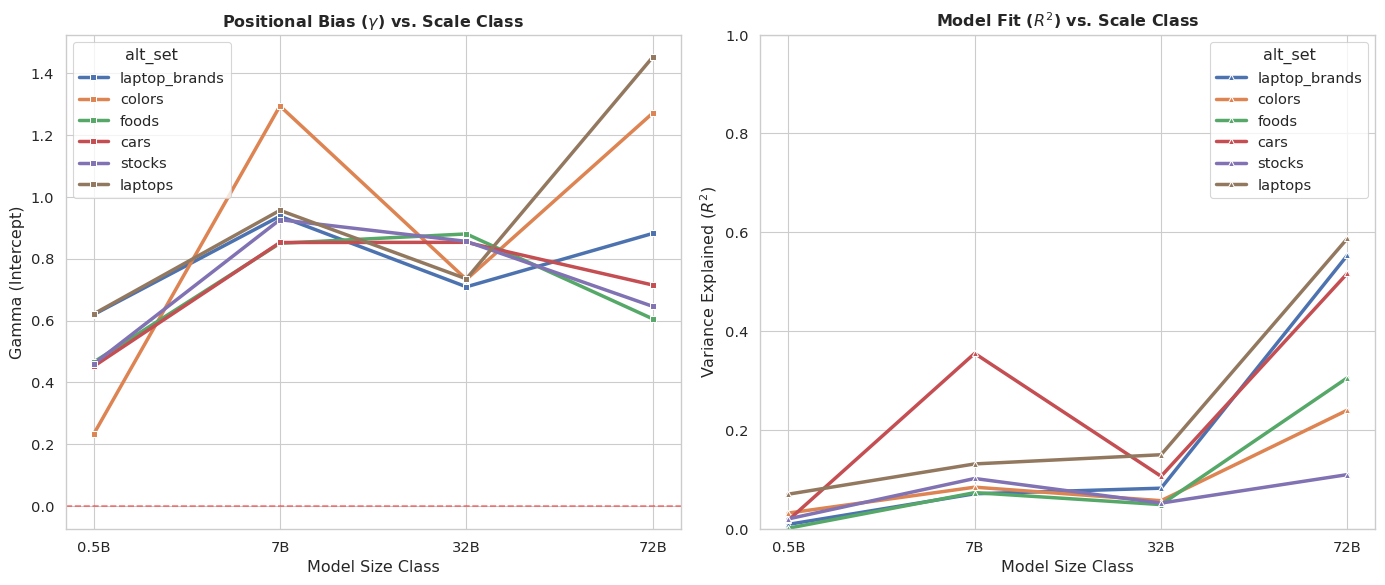

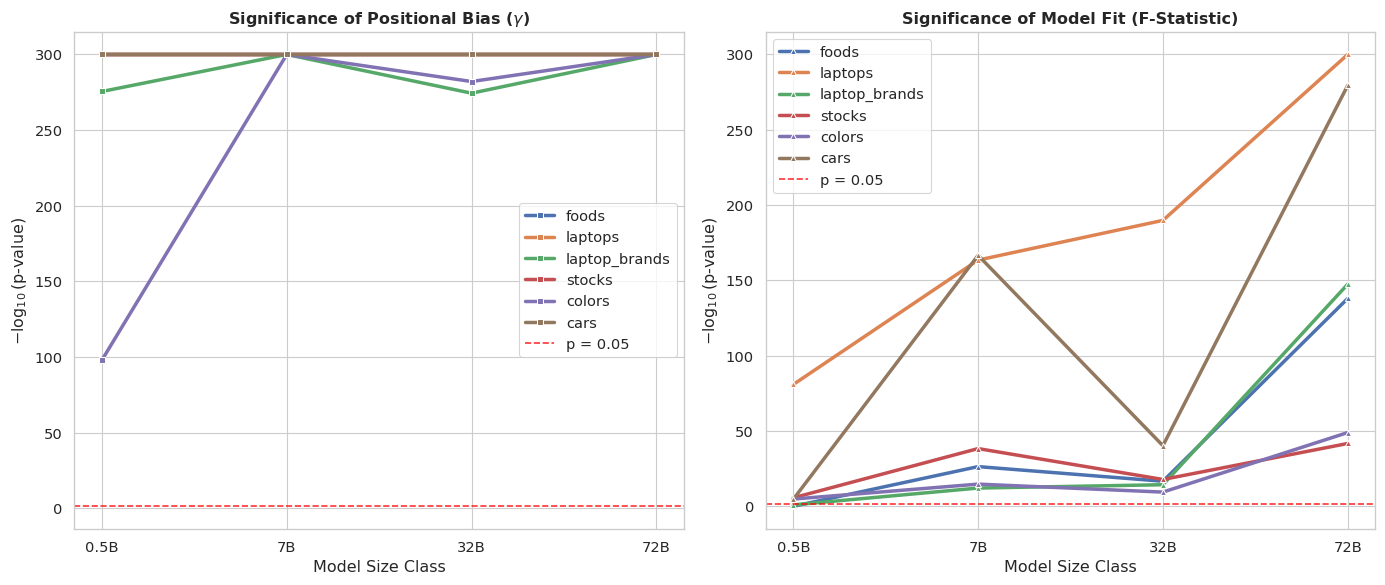

In [62]:
with open("qwen_pt_bt_bias.json", "r") as file:
    data = json.load(file)
df = parse_results_to_dataframe(data)
plot_llm_preferences(df)
plot_statistical_significance(df)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

def plot_pair_regressions(df: pd.DataFrame, results_dict: dict, alt_set_name: str):
    """
    Plots the Actual vs Predicted Log-Odds for every pair of items in a given model fit.
    
    Args:
        df: The raw dataframe containing 'item_a', 'item_b', 'score_a', 'score_b'
        results_dict: The dictionary output from `fit_bradley_terry_to_dict`
        alt_set_name: String for the title (e.g., "72B Model - Laptops")
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    
    # Calculate actual observed Log-Odds
    df = df.copy()
    df['actual_log_odds'] = df['score_a'] - df['score_b']
    
    # Extract parameters from the model fit
    gamma = results_dict['positional_bias_gamma']
    item_scores = results_dict['item_scores']
    
    # Get unique items and create all unique pairs
    items = list(item_scores.keys())
    pairs = list(combinations(items, 2))
    
    # Set up the subplot grid
    n_pairs = len(pairs)
    cols = min(4, n_pairs)
    rows = int(np.ceil(n_pairs / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), sharey=True)
    if n_pairs == 1: axes = np.array([axes])
    axes = axes.flatten()
    
    fig.suptitle(f"Pairwise Regression Fits: {alt_set_name}\n(Positional Bias $\gamma$ = {gamma:.3f})", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    for i, (item1, item2) in enumerate(pairs):
        ax = axes[i]
        u1, u2 = item_scores[item1], item_scores[item2]
        
        # Scenario A: Item1 is Option A, Item2 is Option B
        pred_A = (u1 - u2) + gamma
        # Scenario B: Item2 is Option A, Item1 is Option B
        pred_B = (u2 - u1) + gamma
        
        # Filter the raw data for these specific matchups to plot the scatter points
        mask_A = (df['option_a'] == item1) & (df['option_b'] == item2)
        mask_B = (df['option_a'] == item2) & (df['option_b'] == item1)
        
        # Plot Actual Data Points (Scatter)
        ax.scatter([0]*mask_A.sum(), df[mask_A]['actual_log_odds'], 
                   color='blue', alpha=0.6, label='Actual Obs' if i==0 else "")
        ax.scatter([1]*mask_B.sum(), df[mask_B]['actual_log_odds'], 
                   color='blue', alpha=0.6)
        
        # Plot the Predicted Regression Line
        ax.plot([0, 1], [pred_A, pred_B], color='red', marker='o', 
                linewidth=2.5, markersize=8, label='BT Prediction' if i==0 else "")
        
        # Plot the "Unbiased" baseline (if gamma was 0)
        ax.plot([0, 1], [u1 - u2, u2 - u1], color='gray', linestyle='--', 
                alpha=0.7, label='Unbiased $\Delta U$' if i==0 else "")
        
        # Formatting
        ax.set_title(f"{item1} vs {item2}")
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f"{item1} 1st", f"{item2} 1st"])
        ax.axhline(0, color='black', linewidth=1)
        
        if i % cols == 0:
            ax.set_ylabel("Log-Odds (Option 1 vs 2)")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    fig.legend(loc='upper right', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()



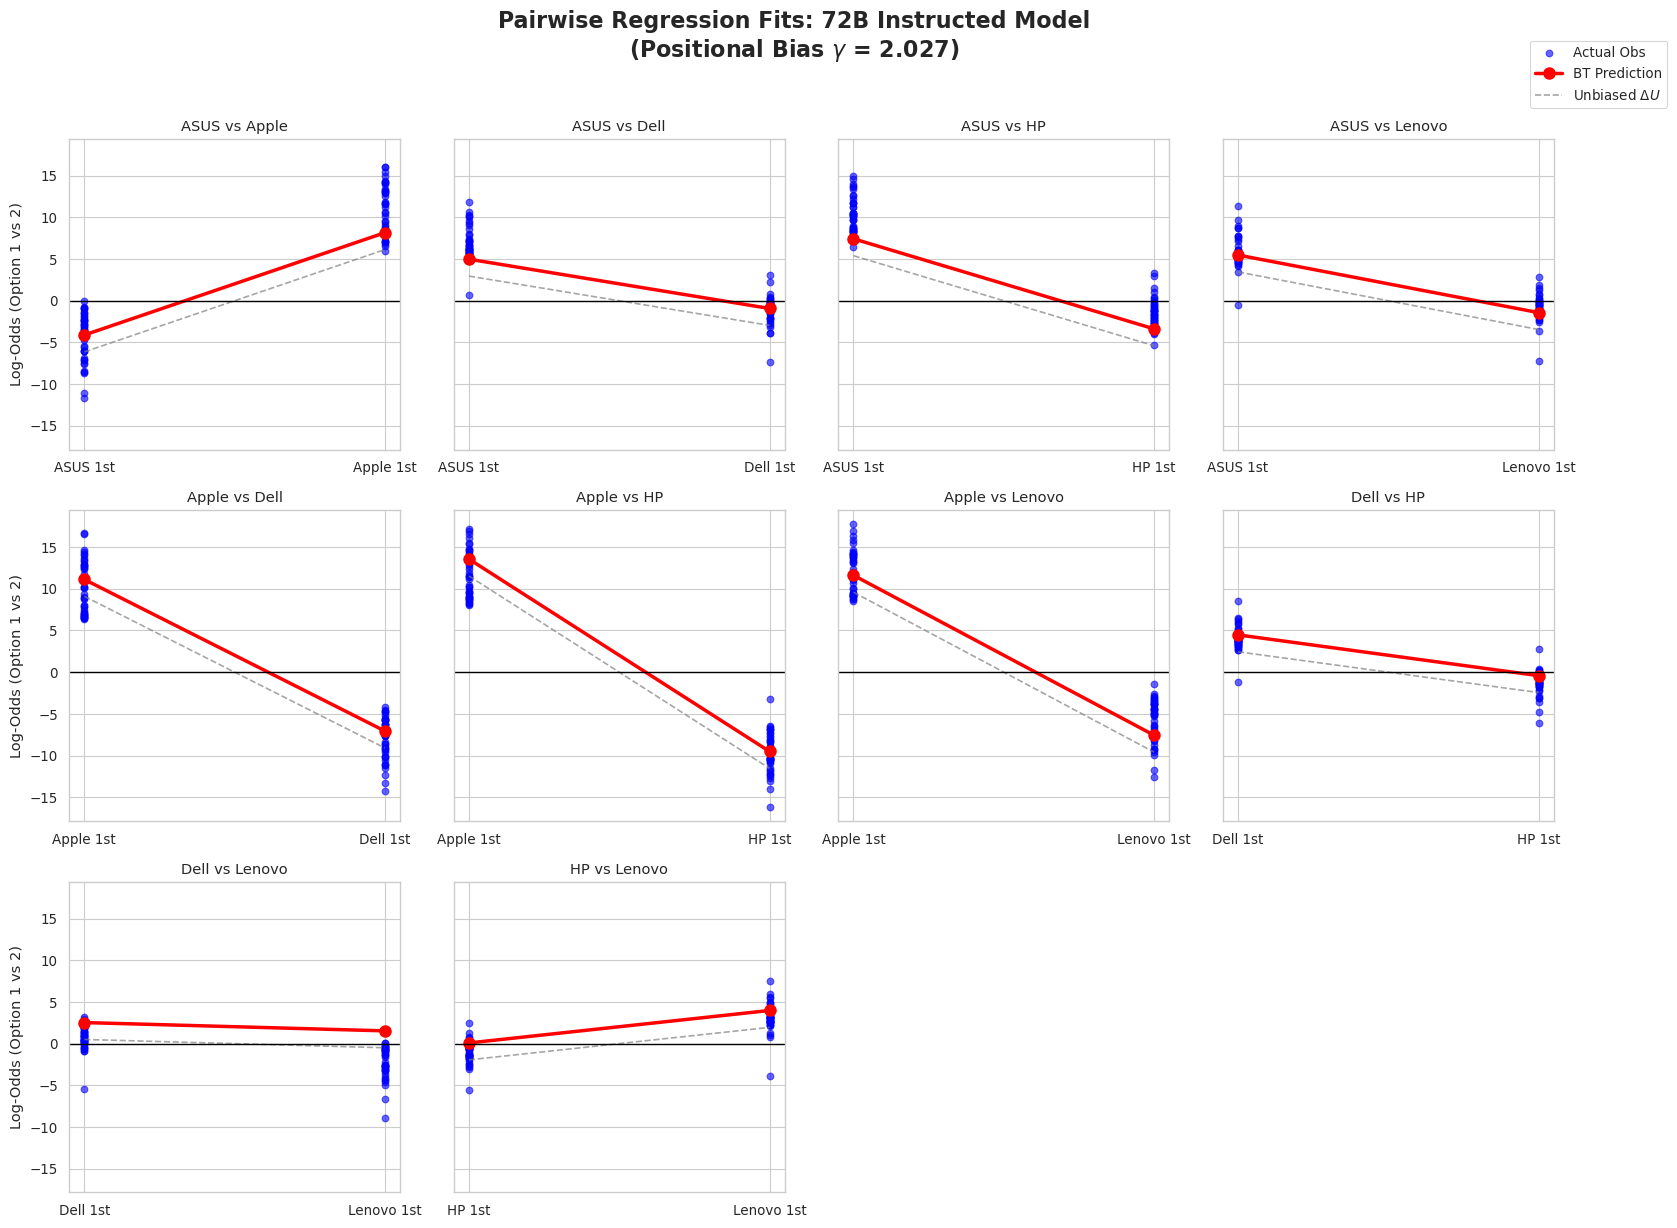

In [53]:
# --- Example Execution ---
# Assuming `df_72b_laptops` is your raw data and `results_72b` is the dict you generated:
for raw_scores, parameters in iterate_experiments('eos_fix_qwen'):
    alternatives = parameters['alternatives']
    model_size = parameters['model_size']
    if alternatives == 'laptop_brands' and model_size == '72':
        item_mapping = create_item_mapping(raw_scores)
        results = fit_bradley_terry_statsmodels(raw_scores, item_mapping)
        plot_pair_regressions(raw_scores, results, "72B Instructed Model")